In [1]:
%load_ext autoreload
%autoreload 2

In [33]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import seaborn as sns

from pathlib import Path
from MITRotor import IEA10MW
from wrf_io import rotor_average
from itertools import product

In [34]:
rotor = IEA10MW()

nElements = 26
nSections = 158

In [35]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [120]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/*/input_sounding")

data = extract_columns(file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * rotor.R + 378

In [121]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [122]:
casenames = [
r'sn030151_vn402010',
r'sn030151_vn201005',
r'sn030151_vn100503',
r'sn030151_vn050251',
r'sn030151_v000000',
r'sn030151_v050251',
r'sn030151_v100503',
r'sn030151_v201005',
r'sn030151_v402010',
r'sn020101_vn402010',
r'sn020101_vn201005',
r'sn020101_vn100503',
r'sn020101_vn050251',
r'sn020101_v000000',
r'sn020101_v050251',
r'sn020101_v100503',
r'sn020101_v201005',
r'sn020101_v402010',
r'sn010050_vn402010',
r'sn010050_vn201005',
r'sn010050_vn100503',
r'sn010050_vn050251',
r'sn010050_v000000',
r'sn010050_v050251',
r'sn010050_v100503',
r'sn010050_v201005',
r'sn010050_v402010',
r's000000_vn402010',
r's000000_vn201005',
r's000000_vn100503',
r's000000_vn050251',
r's000000_v000000',
r's000000_v050251',
r's000000_v100503',
r's000000_v201005',
r's000000_v402010',
r's010050_vn402010',
r's010050_vn201005',
r's010050_vn100503',
r's010050_vn050251',
r's010050_v000000',
r's010050_v050251',
r's010050_v100503',
r's010050_v201005',
r's010050_v402010',
r's020101_vn402010',
r's020101_vn201005',
r's020101_vn100503',
r's020101_vn050251',
r's020101_v000000',
r's020101_v050251',
r's020101_v100503',
r's020101_v201005',
r's020101_v402010',
r's030151_vn402010',
r's030151_vn201005',
r's030151_vn100503',
r's030151_vn050251',
r's030151_v000000',
r's030151_v050251',
r's030151_v100503',
r's030151_v201005',
r's030151_v402010'
]

In [123]:
wrfles_bem = []
for count, name in enumerate(casenames):
    wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/'+casenames[count]+'_lite.npz')))

In [124]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

In [125]:
wrfles_bem[0].keys()

dict_keys(['diameter', 'radius', 'hub_diameter', 'hub_radius', 'hub_height', 'rOverR', 'dx', 'dy', 'dz', 'dt', 'Nx', 'Ny', 'Nz', 'tower_xloc', 'tower_yloc', 'Nsct', 'Nelm', 'uinf', 'omega', 'thrust', 'power_aero', 'power_mech', 'power_gen', 'torque_aero', 'ct', 'cp', 'v0', 'f', 'fn', 'ft', 'l', 'd', 'cl', 'cd', 'aoa', 'v1', 'u', 'v', 'w', 'v_tan', 'vrel', 'phi', 'bpx', 'bpy', 'bpz', 'shapiroM'])

In [126]:
ind_rotor = np.zeros(len(coords), dtype=float)
ct_rotor  = np.zeros(len(coords), dtype=float)

wrf_tsr   = np.zeros(len(coords), dtype=float)

cx_rotor  = np.zeros(len(coords), dtype=float)
W_rotor   = np.zeros(len(coords), dtype=float)
sig_rotor = np.zeros(len(coords), dtype=float)
U_bar_out = np.zeros(len(coords), dtype=float)

pow_rotor = np.zeros(len(coords), dtype=float)
thr_rotor = np.zeros(len(coords), dtype=float)

ind_ann = np.zeros((nElements, len(coords)))
ct_ann  = np.zeros((nElements, len(coords)))

ind_loc = np.zeros((nElements, nSections, len(coords)))
ct_loc  = np.zeros((nElements, nSections, len(coords)))

U_loc  = np.zeros((nElements, nSections, len(coords)))
dir_loc  = np.zeros((nElements, nSections, len(coords)))

shapiro = np.zeros(len(coords), dtype=float)

for count,case in enumerate(casenames):
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    wdir = np.atan2(v_inf,u_inf)

    dir_loc[:,:,count] = wdir.T

    # Compute induction
    r = wrfles_bem[count]['rOverR'] * rotor.R
    r_vec = wrfles_bem[count]['rOverR']

    # Compute induction
    ind = 1 - np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0) / u_inf.T
    # ind = 1 - np.mean(wrfles_bem[count]['u'],axis=0) / u_inf.T

    # ind_non = ind

    ind_non = 1/(2 * np.pi) * np.trapezoid(2 * np.trapezoid(ind.T * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR']), np.linspace(0, 2*np.pi, nSections), axis=-1)

    phi = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))
    Cl = np.mean(wrfles_bem[count]['cl'], axis=0)
    Cd = np.mean(wrfles_bem[count]['cd'], axis=0)

    r =  (np.ones_like(Cd.T) * r).T

    chord = [4.649046,4.844576,5.216862,5.647547,5.931514,5.96353,5.812206,5.569981,5.273268,4.94348,4.598646,4.251929,3.911027,3.581805,3.269938,2.978544,2.70897,2.462014,2.237137,2.035348,1.855479,1.691271,1.526768,1.308778,0.7955106,0.5734]

    chord =  (np.ones_like(Cd.T) * chord).T

    sigma = (3 * chord) / (2 * np.pi * r)

    sig_rotor[count] = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(sigma, np.linspace(0, 2*np.pi, nSections), axis=-1) * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])

    U = np.sqrt(u_inf**2 + v_inf**2)

    tsr = np.mean(wrfles_bem[count]['omega']*wrfles_bem[count]['radius']*2*np.pi/(7*60), axis=0)

    # Rotor-average U
    U_azim = 1 / (2 * np.pi) * np.trapezoid(((u_inf**2 + v_inf**2)**(1/2)).T, np.linspace(0, 2*np.pi, nSections), axis=-1)
    U_bar = 2 * np.trapezoid(U_azim * r_vec, r_vec)

    U_bar = 7
    # U_bar_out[count] = U_bar

    theta = np.linspace(0, 2*np.pi, nSections)

    # Vax = (
    #         (U/7 * (1 - ind_non.T)).T
    #         * np.cos(wdir.T * np.cos(theta))
    #         * np.cos(wdir.T * np.sin(theta))
    #     )
    Vax = (
            (U/U_bar * (1 - ind_non.T)).T
            * np.cos(wdir.T)
        )
    aprime=0
    # Vtan = (
    #         (1 + aprime) * tsr * r/wrfles_bem[count]['radius']
    #         - (U/7 * (1 - ind_non.T)).T
    #         * np.cos(wdir.T * np.sin(theta))
    #         * np.sin(wdir.T * np.cos(theta))
    #     )
    
    Vtan = (
            (1 + aprime) * tsr * r/wrfles_bem[count]['radius']
            - (U/U_bar * (1 - ind_non.T)).T
            * np.cos(theta)
            * np.sin(wdir.T)
        )
    
    W = np.sqrt(Vax**2 + Vtan**2)

    # Local Magnitude of U
    # W = np.mean(wrfles_bem[count]['vrel'], axis=0) / ((u_inf**2 + v_inf**2)**(1/2)).T

    # W = np.mean(wrfles_bem[count]['vrel'], axis=0) / U_bar

    W_rotor[count] = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(W, np.linspace(0, 2*np.pi, nSections), axis=-1) * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    cx_rotor[count] = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(Cax, np.linspace(0, 2*np.pi, nSections), axis=-1) * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])

    # Local CT
    ct = sigma * W**2 * Cax

    alpha = (W**2 - 1) * (((np.cos(wdir * np.sin(phi.T)) * np.cos(wdir * np.cos(phi.T)))**2).T - ((np.cos(wdir * np.sin(phi.T)) * np.sin(wdir * np.cos(phi.T)))**2).T)**2
    beta = 2 * np.mean(wrfles_bem[count]['omega'], axis=0) * r_vec * np.cos(wdir * np.sin(phi.T)) * np.sin(wdir * np.cos(phi.T))
    gamma = -np.mean(wrfles_bem[count]['omega'], axis=0)**2 * r_vec**2

    # U_test = 1 / (1 - ind.T) * (-beta + np.sqrt(beta**2 - 4*alpha.T*gamma))/(2 * alpha.T)

    # U_loc[:,:,count] = U_test.T
    U_loc[:,:,count] = U.T/U_bar

    ind_loc[:,:,count] = ind
    ct_loc[:,:,count]  = ct

    ct_annular  = 1/(2 * np.pi) * np.trapezoid(ct, np.linspace(0, 2*np.pi, nSections), axis=-1)
    ind_annular = 1/(2 * np.pi) * np.trapezoid(ind, np.linspace(0, 2*np.pi, nSections), axis=-1)

    ind_ann[:,count] = ind_annular
    ct_ann[:,count]  = ct_annular

    ct_rotor[count]  = 2 * np.trapezoid(ct_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])
    ind_rotor[count] = 2 * np.trapezoid(ind_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])

    thr_rotor[count] = np.mean(wrfles_bem[count]['thrust'], axis=0)
    pow_rotor[count] = np.mean(wrfles_bem[count]['power_mech'], axis=0)

    shapiro[count] = wrfles_bem[count]['shapiroM'][1]

    wrf_tsr[count] = tsr


/tmp/ipykernel_1652187/384340910.py:137: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  thr_rotor[count] = np.mean(wrfles_bem[count]['thrust'], axis=0)
/tmp/ipykernel_1652187/384340910.py:138: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pow_rotor[count] = np.mean(wrfles_bem[count]['power_mech'], axis=0)
/tmp/ipykernel_1652187/384340910.py:140: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  shapiro[count] = wrfles_bem[count]['shapiroM'][1]
/tmp/ipykernel_1652187/384

In [42]:
U_loc

array([[[1.00285714, 1.00285714, 1.00285714, ..., 0.99714286,
         0.99714286, 0.99714286],
        [1.00285714, 1.00285714, 1.00285714, ..., 0.99714286,
         0.99714286, 0.99714286],
        [1.00285714, 1.00285714, 1.00285714, ..., 0.99714286,
         0.99714286, 0.99714286],
        ...,
        [1.00285714, 1.00285714, 1.00285714, ..., 0.99714286,
         0.99714286, 0.99714286],
        [1.00285714, 1.00285714, 1.00285714, ..., 0.99714286,
         0.99714286, 0.99714286],
        [1.00285714, 1.00285714, 1.00285714, ..., 0.99714286,
         0.99714286, 0.99714286]],

       [[0.98483813, 0.98453213, 0.98445614, ..., 1.01559421,
         1.01566787, 1.01596449],
        [0.98485108, 0.98454554, 0.98446971, ..., 1.01558057,
         1.01565407, 1.01595026],
        [0.98488992, 0.98458576, 0.98451042, ..., 1.01553966,
         1.0156127 , 1.01590757],
        ...,
        [0.98488992, 0.98458576, 0.98451042, ..., 1.01553966,
         1.0156127 , 1.01590757],
        [0.9

In [12]:
# Plot rotor

fig, ax = plt.subplots(nrows=9, ncols=7, figsize=(25, 25), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[coords[count][1],coords[count][0]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[coords[count][1],coords[count][0]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)

    mesh = ax[coords[count][1],coords[count][0]].scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=60, edgecolor='none',color='#176d2e',alpha=1)

    ax[coords[count][1],coords[count][0]].set_xlim([0,0.6])
    ax[coords[count][1],coords[count][0]].set_ylim([0,1.5])


line_y = -0.04  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_x_start, line_x_end, 8)+0.095  # Adjust the number of points and spacing
labels = ['-6.0', '-4.0', '-2.0', '0.0', '2.0', '4.0', '6.0']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(pos, line_y - 0.03, label, ha='center', fontsize=22)

# # Add a title for the number line
fig.text(0.52, line_y - 0.075, 'Speed shear, $\Delta u$ over rotor [m/s]', ha='center', fontsize=25)

line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = -0.04, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_y_start, line_y_end, 10)+0.074  # Adjust the number of points and spacing
labels = ['-80', '-40', '-20', '-10', '0', '10', '20', '40', '80']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_y - 0.01,pos, label, ha='center', fontsize=22)

# # Add a title for the number line
fig.text(-0.075,0.46, 'Direction shear, $\Delta \\beta$ over rotor [deg]', ha='center', fontsize=25,rotation=90)

plt.show()

/tmp/ipykernel_1652187/987102720.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1],coords[count][0]].scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=60, edgecolor='none',color='#176d2e',alpha=1)


In [127]:
# Define the specific equation (e.g., linear: y = a * x + b)
def madsen_func(CT, a, b, c):

    # k1 = 0.0883
    # k2 = 0.0586
    # k3 = 0.2460

    return a * CT**3 + b * CT**2 + c * CT

In [128]:
veer  = np.array([-80,-40,-20,-10,0,10,20,40,80])
shear = np.array([-6,-4,-2,0,2,4,6])

training = [pair for pair in product(shear, veer)]

# indices_80 = [i for i, (s, v) in enumerate(training) if (abs(v) == 80 and abs(s) == 0)]
# indices_40 = [i for i, (s, v) in enumerate(training) if (abs(v) == 40 and abs(s) == 0)]
# indices_20 = [i for i, (s, v) in enumerate(training) if (abs(v) == 20 and abs(s) == 0)]
# indices_10 = [i for i, (s, v) in enumerate(training) if (abs(v) == 10 and abs(s) == 0)]
# indices_00 = [i for i, (s, v) in enumerate(training) if (abs(v) == 0 and abs(s) == 0)]

indices_80 = [i for i, (s, v) in enumerate(training) if (v == 80 and abs(s) == 0)]
indices_40 = [i for i, (s, v) in enumerate(training) if (v == 40 and abs(s) == 0)]
indices_20 = [i for i, (s, v) in enumerate(training) if (v == 20 and abs(s) == 0)]
indices_10 = [i for i, (s, v) in enumerate(training) if (v == 10 and abs(s) == 0)]
indices_00 = [i for i, (s, v) in enumerate(training) if (v == 0 and abs(s) == 0)]
# indices_00 = 31


In [129]:
indices_10

[32]

In [130]:
indices_20

[33]

In [131]:
# V80

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, ind_rotor[indices_80])
ct_mom = np.append(ct_mom, ct_rotor[indices_80])

# a_mom = ind_rotor[indices_80]
# ct_mom = ct_rotor[indices_80]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v80, b_fit_v80, c_fit_v80 = params
# print(f"Fitted parameters: a = {a_fit_v80:.3f}, b = {b_fit_v80:.3f}, c = {c_fit_v80:.3f},")
print(f"Fitted parameters: {a_fit_v80:.3f}, {b_fit_v80:.3f}, {c_fit_v80:.3f}")

np.save("./rotor_coefficients/shapiro/v80_10MW_rotor_coefficients.npy", [a_fit_v80,b_fit_v80,c_fit_v80])

# Generate fitted values
x_fit_v80 = np.linspace(0, 2, 100)
y_fit_v80 = madsen_func(x_fit_v80, a_fit_v80, b_fit_v80, c_fit_v80)

Fitted parameters: 0.226, 0.012, 0.253


In [132]:
# V40

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, ind_rotor[indices_40])
ct_mom = np.append(ct_mom, ct_rotor[indices_40])

# a_mom = ind_rotor[indices_40]
# ct_mom = ct_rotor[indices_40]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v40, b_fit_v40, c_fit_v40 = params
print(f"Fitted parameters: a = {a_fit_v40:.3f}, b = {b_fit_v40:.3f}, c = {c_fit_v40:.3f},")
print(f"Fitted parameters: {a_fit_v40:.3f}, {b_fit_v40:.3f}, {c_fit_v40:.3f}")

np.save("./rotor_coefficients/shapiro/v40_10MW_rotor_coefficients.npy", [a_fit_v40,b_fit_v40,c_fit_v40])

# Generate fitted values
x_fit_v40 = np.linspace(0, 2, 100)
y_fit_v40 = madsen_func(x_fit_v40, a_fit_v40, b_fit_v40, c_fit_v40)

Fitted parameters: a = 0.149, b = 0.033, c = 0.252,
Fitted parameters: 0.149, 0.033, 0.252


In [133]:
# V20

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, ind_rotor[indices_20])
ct_mom = np.append(ct_mom, ct_rotor[indices_20])

# a_mom = ind_rotor[indices_20]
# ct_mom = ct_rotor[indices_20]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v20, b_fit_v20, c_fit_v20 = params
print(f"Fitted parameters: a = {a_fit_v20:.3f}, b = {b_fit_v20:.3f}, c = {c_fit_v20:.3f},")
print(f"Fitted parameters: {a_fit_v20:.3f}, {b_fit_v20:.3f}, {c_fit_v20:.3f}")

np.save("./rotor_coefficients/shapiro/v20_10MW_rotor_coefficients.npy", [a_fit_v20,b_fit_v20,c_fit_v20])

# Generate fitted values
x_fit_v20 = np.linspace(0, 2, 100)
y_fit_v20 = madsen_func(x_fit_v20, a_fit_v20, b_fit_v20, c_fit_v20)

Fitted parameters: a = 0.114, b = 0.042, c = 0.251,
Fitted parameters: 0.114, 0.042, 0.251


In [134]:
# V10

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, ind_rotor[indices_10])
ct_mom = np.append(ct_mom, ct_rotor[indices_10])

# a_mom = ind_rotor[indices_10]
# ct_mom = ct_rotor[indices_10]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v10, b_fit_v10, c_fit_v10 = params
print(f"Fitted parameters: a = {a_fit_v10:.3f}, b = {b_fit_v10:.3f}, c = {c_fit_v10:.3f},")
print(f"Fitted parameters: {a_fit_v10:.3f}, {b_fit_v10:.3f}, {c_fit_v10:.3f}")

np.save("./rotor_coefficients/shapiro/v10_10MW_rotor_coefficients.npy", [a_fit_v10,b_fit_v10,c_fit_v10])

# Generate fitted values
x_fit_v10 = np.linspace(0, 2, 100)
y_fit_v10 = madsen_func(x_fit_v10, a_fit_v10, b_fit_v10, c_fit_v10)

Fitted parameters: a = 0.103, b = 0.045, c = 0.251,
Fitted parameters: 0.103, 0.045, 0.251


In [135]:
# V00

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, ind_rotor[indices_00])
ct_mom = np.append(ct_mom, ct_rotor[indices_00])

# a_mom = ind_rotor[indices_00]
# ct_mom = ct_rotor[indices_00]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v00, b_fit_v00, c_fit_v00 = params
print(f"Fitted parameters: a = {a_fit_v00:.3f}, b = {b_fit_v00:.3f}, c = {c_fit_v00:.3f},")
print(f"Fitted parameters: {a_fit_v00:.3f}, {b_fit_v00:.3f}, {c_fit_v00:.3f}")

np.save("./rotor_coefficients/shapiro/v00_10MW_rotor_coefficients.npy", [a_fit_v00,b_fit_v00,c_fit_v00])

# Generate fitted values
x_fit_v00 = np.linspace(0, 2, 100)
y_fit_v00 = madsen_func(x_fit_v00, a_fit_v00, b_fit_v00, c_fit_v00)

Fitted parameters: a = 0.097, b = 0.046, c = 0.251,
Fitted parameters: 0.097, 0.046, 0.251


In [136]:
wrf_tsr[4]

np.float64(9.040505677461624)

In [137]:
print("if int(abs(self.veer)) == 0:")
print(f"    a,b,c = {a_fit_v00:.3f}, {b_fit_v00:.3f}, {c_fit_v00:.3f}")
print("elif int(abs(self.veer)) == 1:")
print(f"    a,b,c = {a_fit_v10:.3f}, {b_fit_v10:.3f}, {c_fit_v10:.3f}")
print("elif int(abs(self.veer)) == 2:")
print(f"    a,b,c = {a_fit_v20:.3f}, {b_fit_v20:.3f}, {c_fit_v20:.3f}")
print("elif int(abs(self.veer)) == 4:")
print(f"    a,b,c = {a_fit_v40:.3f}, {b_fit_v40:.3f}, {c_fit_v40:.3f}")
print("elif int(abs(self.veer)) == 8:")
print(f"    a,b,c = {a_fit_v80:.3f}, {b_fit_v80:.3f}, {c_fit_v80:.3f}")

if int(abs(self.veer)) == 0:
    a,b,c = 0.097, 0.046, 0.251
elif int(abs(self.veer)) == 1:
    a,b,c = 0.103, 0.045, 0.251
elif int(abs(self.veer)) == 2:
    a,b,c = 0.114, 0.042, 0.251
elif int(abs(self.veer)) == 4:
    a,b,c = 0.149, 0.033, 0.252
elif int(abs(self.veer)) == 8:
    a,b,c = 0.226, 0.012, 0.253


In [138]:
sns.color_palette("tab10",5)

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353)]

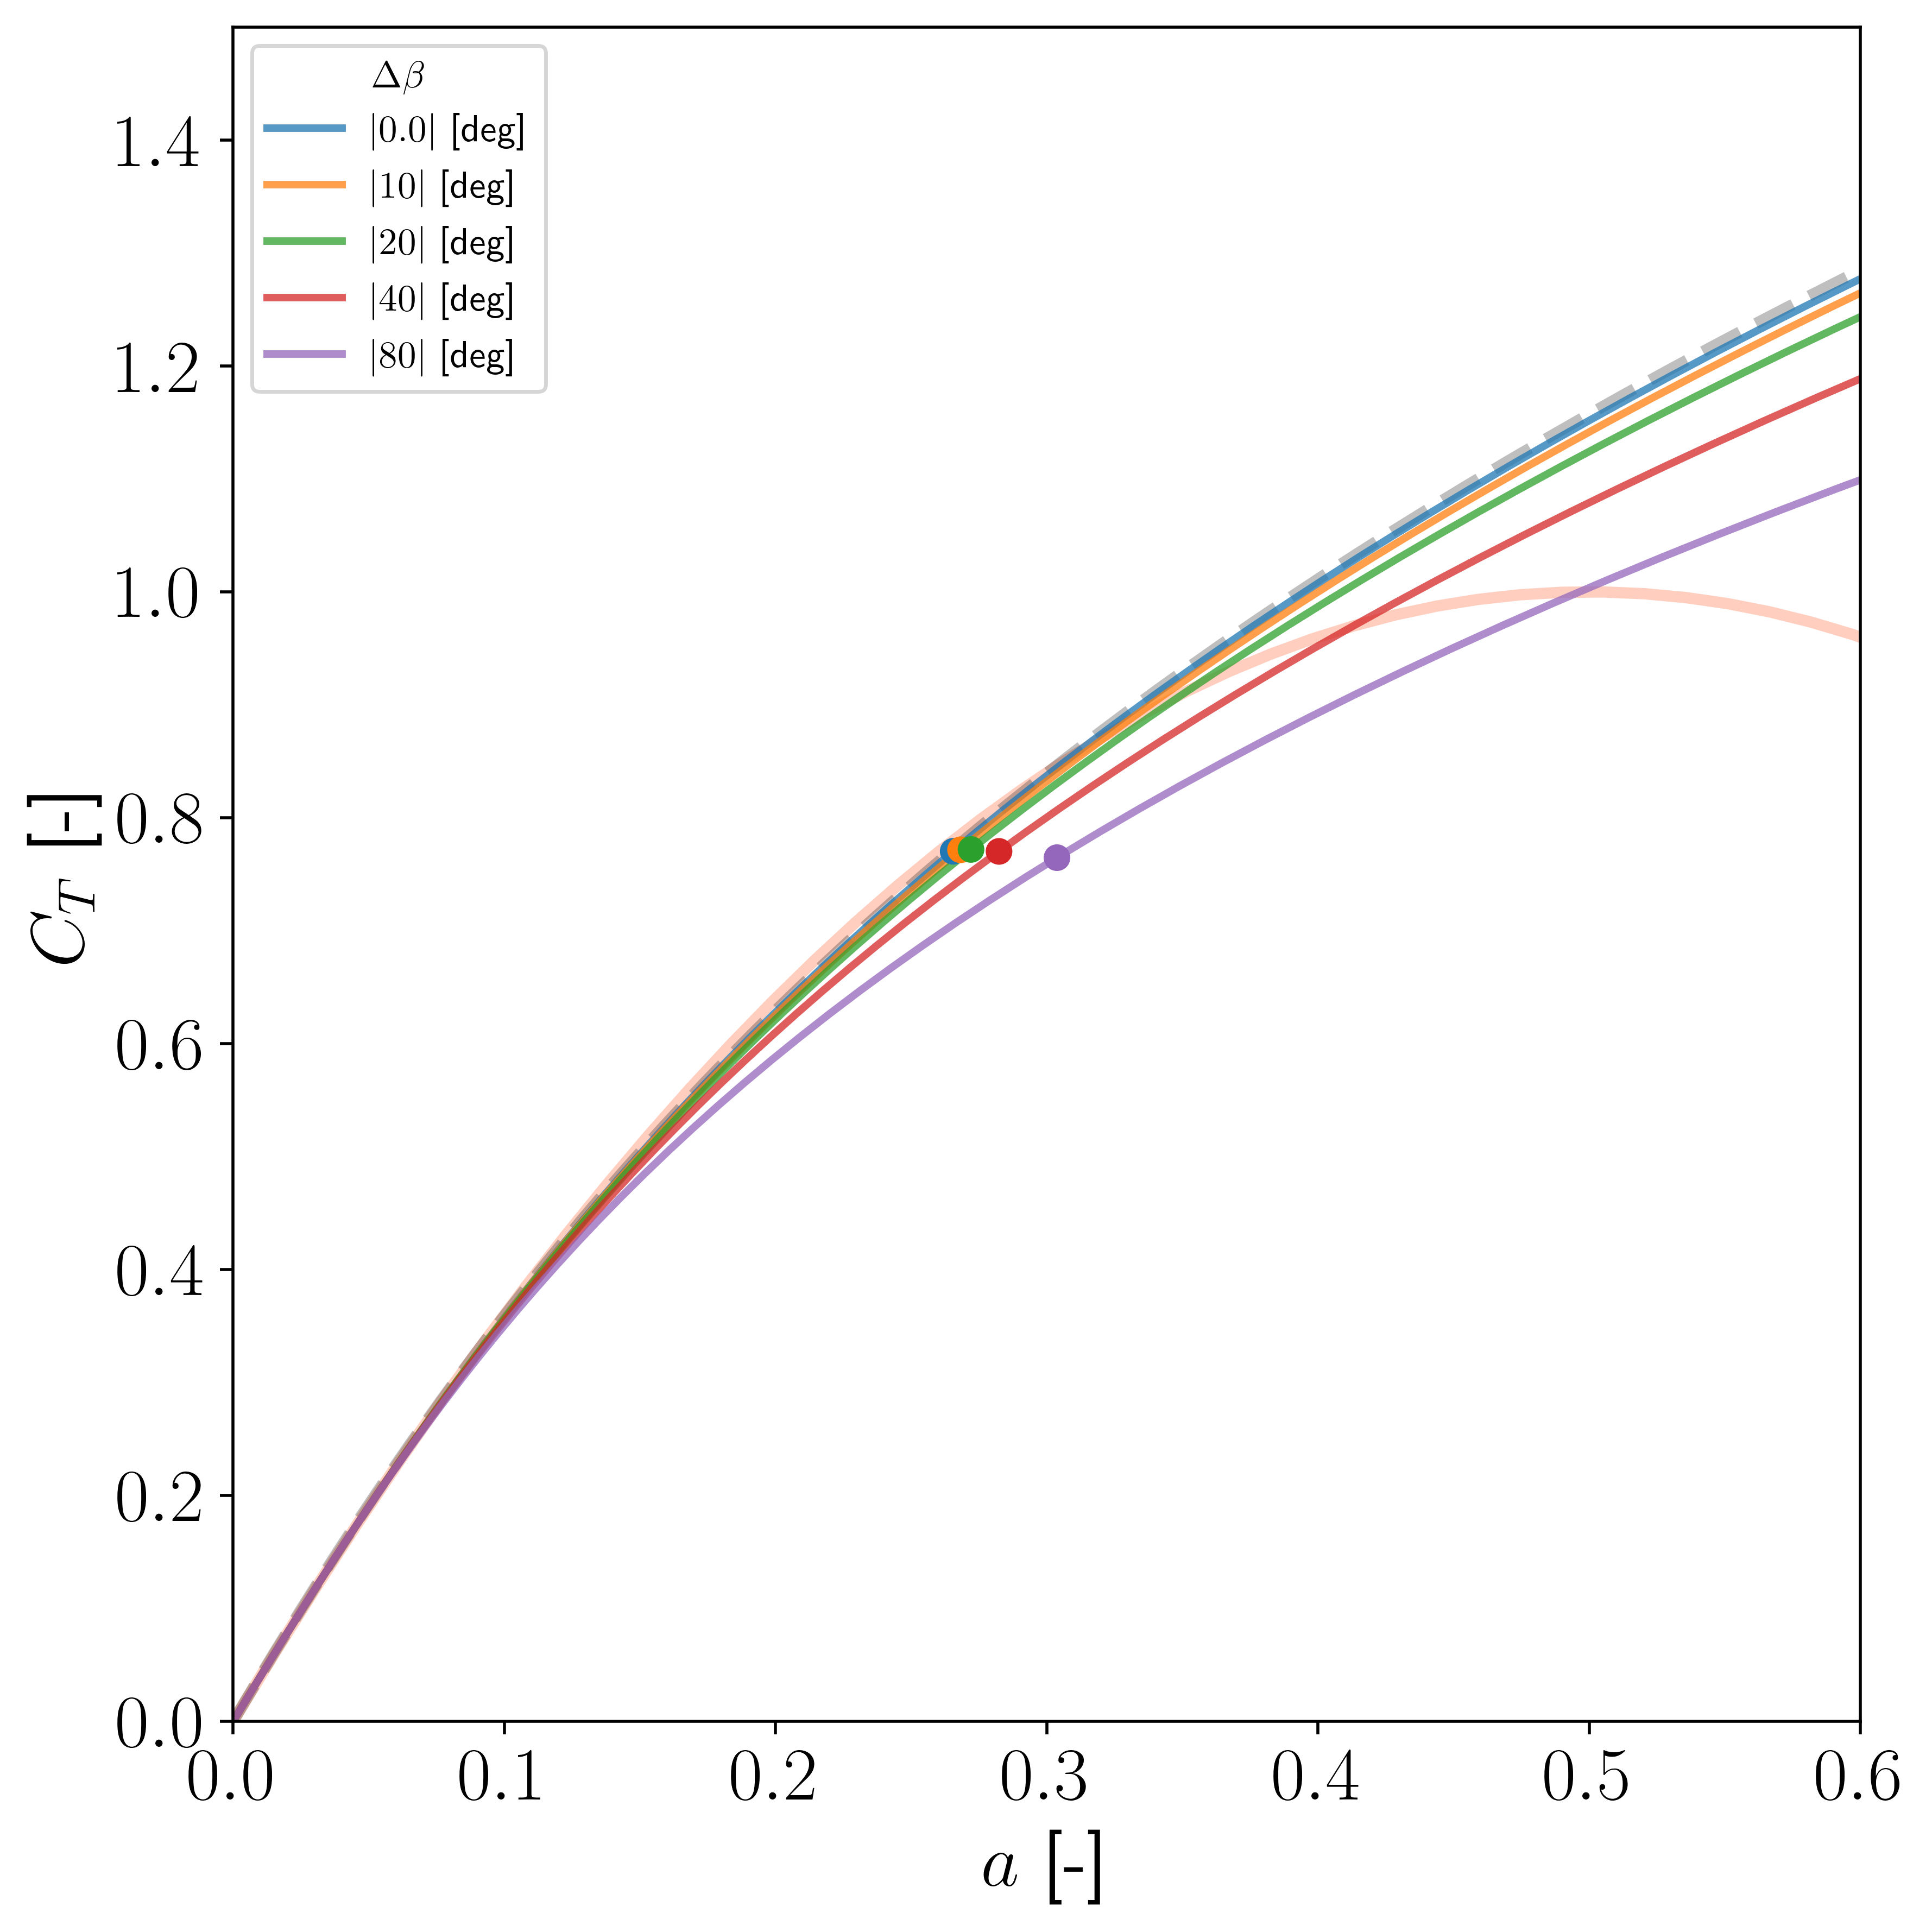

In [272]:
colors = sns.color_palette("tab10",5)

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)
# fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True,sharex=True, sharey=True)


a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$|0.0|$ [deg]')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$|10|$ [deg]')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$|20|$ [deg]')
ax.plot(y_fit_v40, x_fit_v40, color=colors[3],linewidth=2,zorder=2,alpha=0.75,label='$|40|$ [deg]')
ax.plot(y_fit_v80, x_fit_v80, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$|80|$ [deg]')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.5])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

# mesh = ax.scatter(ind_rotor[31], ct_rotor[31], s=100, edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_00)):
    mesh = ax.scatter(ind_rotor[indices_00[i]], ct_rotor[indices_00[i]], s=50, edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    mesh = ax.scatter(ind_rotor[indices_10[i]], ct_rotor[indices_10[i]], s=50, edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    mesh = ax.scatter(ind_rotor[indices_20[i]], ct_rotor[indices_20[i]], s=50, edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    mesh = ax.scatter(ind_rotor[indices_40[i]], ct_rotor[indices_40[i]], s=50, edgecolor='none',color=colors[3],zorder=3)

for i in range(len(indices_80)):
    mesh = ax.scatter(ind_rotor[indices_80[i]], ct_rotor[indices_80[i]], s=50, edgecolor='none',color=colors[4],zorder=3)

# mesh = ax.scatter(ind_rotor[indices_00], ct_rotor[indices_00], s=50, edgecolor='none',color=colors[0],zorder=3)


np.save("./rotor_coefficients/shapiro/v0_10MW_rotor_averages.npy", [ind_rotor,ct_rotor])

ax.legend(title='$\Delta \\beta$')

# fig.text(0.4,0.30, f'Coefficients with Shapiro correction:', ha='left', fontsize=12,rotation=0,color='k')
# fig.text(0.4,0.25, f'$a = {a_fit_v0:0.2f}C_T^3 + {b_fit_v0:0.2f}C_T^2 + {c_fit_v0:0.2f}C_T$', ha='left', fontsize=12,rotation=0,color='green')
# fig.text(0.4,0.20, f'$a = {a_fit_v2:0.2f}C_T^3 + {b_fit_v2:0.2f}C_T^2 + {c_fit_v2:0.2f}C_T$', ha='left', fontsize=12,rotation=0,color='blue')
# fig.text(0.4,0.15, f'$a = {a_fit_v4:0.2f}C_T^3 + {b_fit_v4:0.2f}C_T^2 + {c_fit_v4:0.2f}C_T$', ha='left', fontsize=12,rotation=0,color='red')

# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)

plt.show()

In [60]:
print('\n------------ B = |80| ------------')
for i in range(len(indices_80)):
    print(f's: {training[indices_80[i]][0]:2.0f}, v: {training[indices_80[i]][1]:3.0f}: CT = {ct_rotor[indices_80[i]]:.4f}, a = {ind_rotor[indices_80[i]]:.5f}, WRF_p = {pow_rotor[indices_80[i]]:10.2f}, WRF_t = {thr_rotor[indices_80[i]]:9.2f}')

print('\n------------ B = |40| ------------')
for i in range(len(indices_40)):
    print(f's: {training[indices_40[i]][0]:2.0f}, v: {training[indices_40[i]][1]:3.0f}: CT = {ct_rotor[indices_40[i]]:.4f}, a = {ind_rotor[indices_40[i]]:.5f}, WRF_p = {pow_rotor[indices_40[i]]:10.2f}, WRF_t = {thr_rotor[indices_40[i]]:9.2f}')

print('\n------------ B = |20| ------------')

for i in range(len(indices_20)):
    print(f's: {training[indices_20[i]][0]:2.0f}, v: {training[indices_20[i]][1]:3.0f}: CT = {ct_rotor[indices_20[i]]:.4f}, a = {ind_rotor[indices_20[i]]:.5f}, WRF_p = {pow_rotor[indices_20[i]]:10.2f}, WRF_t = {thr_rotor[indices_20[i]]:9.2f}')

print('\n------------ B = |10| ------------')

for i in range(len(indices_10)):
    print(f's: {training[indices_10[i]][0]:2.0f}, v: {training[indices_10[i]][1]:3.0f}: CT = {ct_rotor[indices_10[i]]:.4f}, a = {ind_rotor[indices_10[i]]:.5f}, WRF_p = {pow_rotor[indices_10[i]]:10.2f}, WRF_t = {thr_rotor[indices_10[i]]:9.2f}')

print('\n------------ B = |0| ------------')

for i in range(len(indices_00)):
    print(f's: {training[indices_00[i]][0]:2.0f}, v: {training[indices_00[i]][1]:3.0f}: CT = {ct_rotor[indices_00[i]]:.4f}, a = {ind_rotor[indices_00[i]]:.5f}, WRF_p = {pow_rotor[indices_00[i]]:10.2f}, WRF_t = {thr_rotor[indices_00[i]]:9.2f}')


------------ B = |80| ------------
s: -6, v: -80: CT = 1.0721, a = 0.27581, WRF_p = 3217340.50, WRF_t = 686505.88
s: -6, v:  80: CT = 1.0112, a = 0.31327, WRF_p = 3027726.50, WRF_t = 714653.94
s: -4, v: -80: CT = 1.0717, a = 0.27262, WRF_p = 3123568.75, WRF_t = 685672.31
s: -4, v:  80: CT = 1.0093, a = 0.30802, WRF_p = 2920346.25, WRF_t = 712770.06
s: -2, v: -80: CT = 1.0713, a = 0.27088, WRF_p = 3067540.50, WRF_t = 685237.56
s: -2, v:  80: CT = 1.0084, a = 0.30482, WRF_p = 2859769.50, WRF_t = 712006.75
s:  0, v: -80: CT = 1.0708, a = 0.27034, WRF_p = 3047114.75, WRF_t = 685026.31
s:  0, v:  80: CT = 1.0077, a = 0.30381, WRF_p = 2838331.25, WRF_t = 711706.81
s:  2, v: -80: CT = 1.0703, a = 0.27075, WRF_p = 3063471.00, WRF_t = 685091.44
s:  2, v:  80: CT = 1.0076, a = 0.30461, WRF_p = 2857938.25, WRF_t = 712051.38
s:  4, v: -80: CT = 1.0698, a = 0.27230, WRF_p = 3115617.50, WRF_t = 685415.88
s:  4, v:  80: CT = 1.0076, a = 0.30750, WRF_p = 2916608.00, WRF_t = 712854.19
s:  6, v: -80: C

TypeError: object of type 'int' has no len()

In [91]:
power = np.array([3047114.75, 3098877.00, 3118062.75, 3118720.25, 3110896.25, 3093108.00, 3065985.25, 2991878.75, 2838331.25])

thrust = np.array([685026.31, 701244.62, 709146.56, 712368.00, 714829.81, 716384.19, 717014.75, 716125.00, 711706.81])

CT = np.array([0.7114,0.7831,0.8086, 0.8167, 0.8210, 0.8213,0.8175,0.7995,0.7387])

induction = np.array([0.27034, 0.26538, 0.26376, 0.26411, 0.26554, 0.26825, 0.27211, 0.28243, 0.30381])

In [139]:
ind_ubar = [31,32,33,34,35]

wrf_pow = np.zeros_like(casenames, dtype='float')
wrf_thr = np.zeros_like(casenames, dtype='float')
wrf_cot = np.zeros_like(casenames, dtype='float')
wrf_ind = np.zeros_like(casenames, dtype='float')


for i in range(len(ind_ubar)):
    wrf_pow[i] = pow_rotor[ind_ubar[i]]
    wrf_thr[i] = thr_rotor[ind_ubar[i]]
    wrf_cot[i] = ct_rotor[ind_ubar[i]]
    wrf_ind[i] = ind_rotor[ind_ubar[i]]

In [140]:
import matplotlib.colors as mcolors
from wrf_io import postproc

power_dev     = postproc.per_error(wrf_pow, wrf_pow[0])
thrust_dev    = postproc.per_error(wrf_thr, wrf_thr[0])
induction_dev = postproc.per_error(wrf_ind, wrf_ind[0])

In [141]:
n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-15, vmax=15)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-6, vmax=6)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-13, vmax=13)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in induction_dev]  # Map power to discrete colors

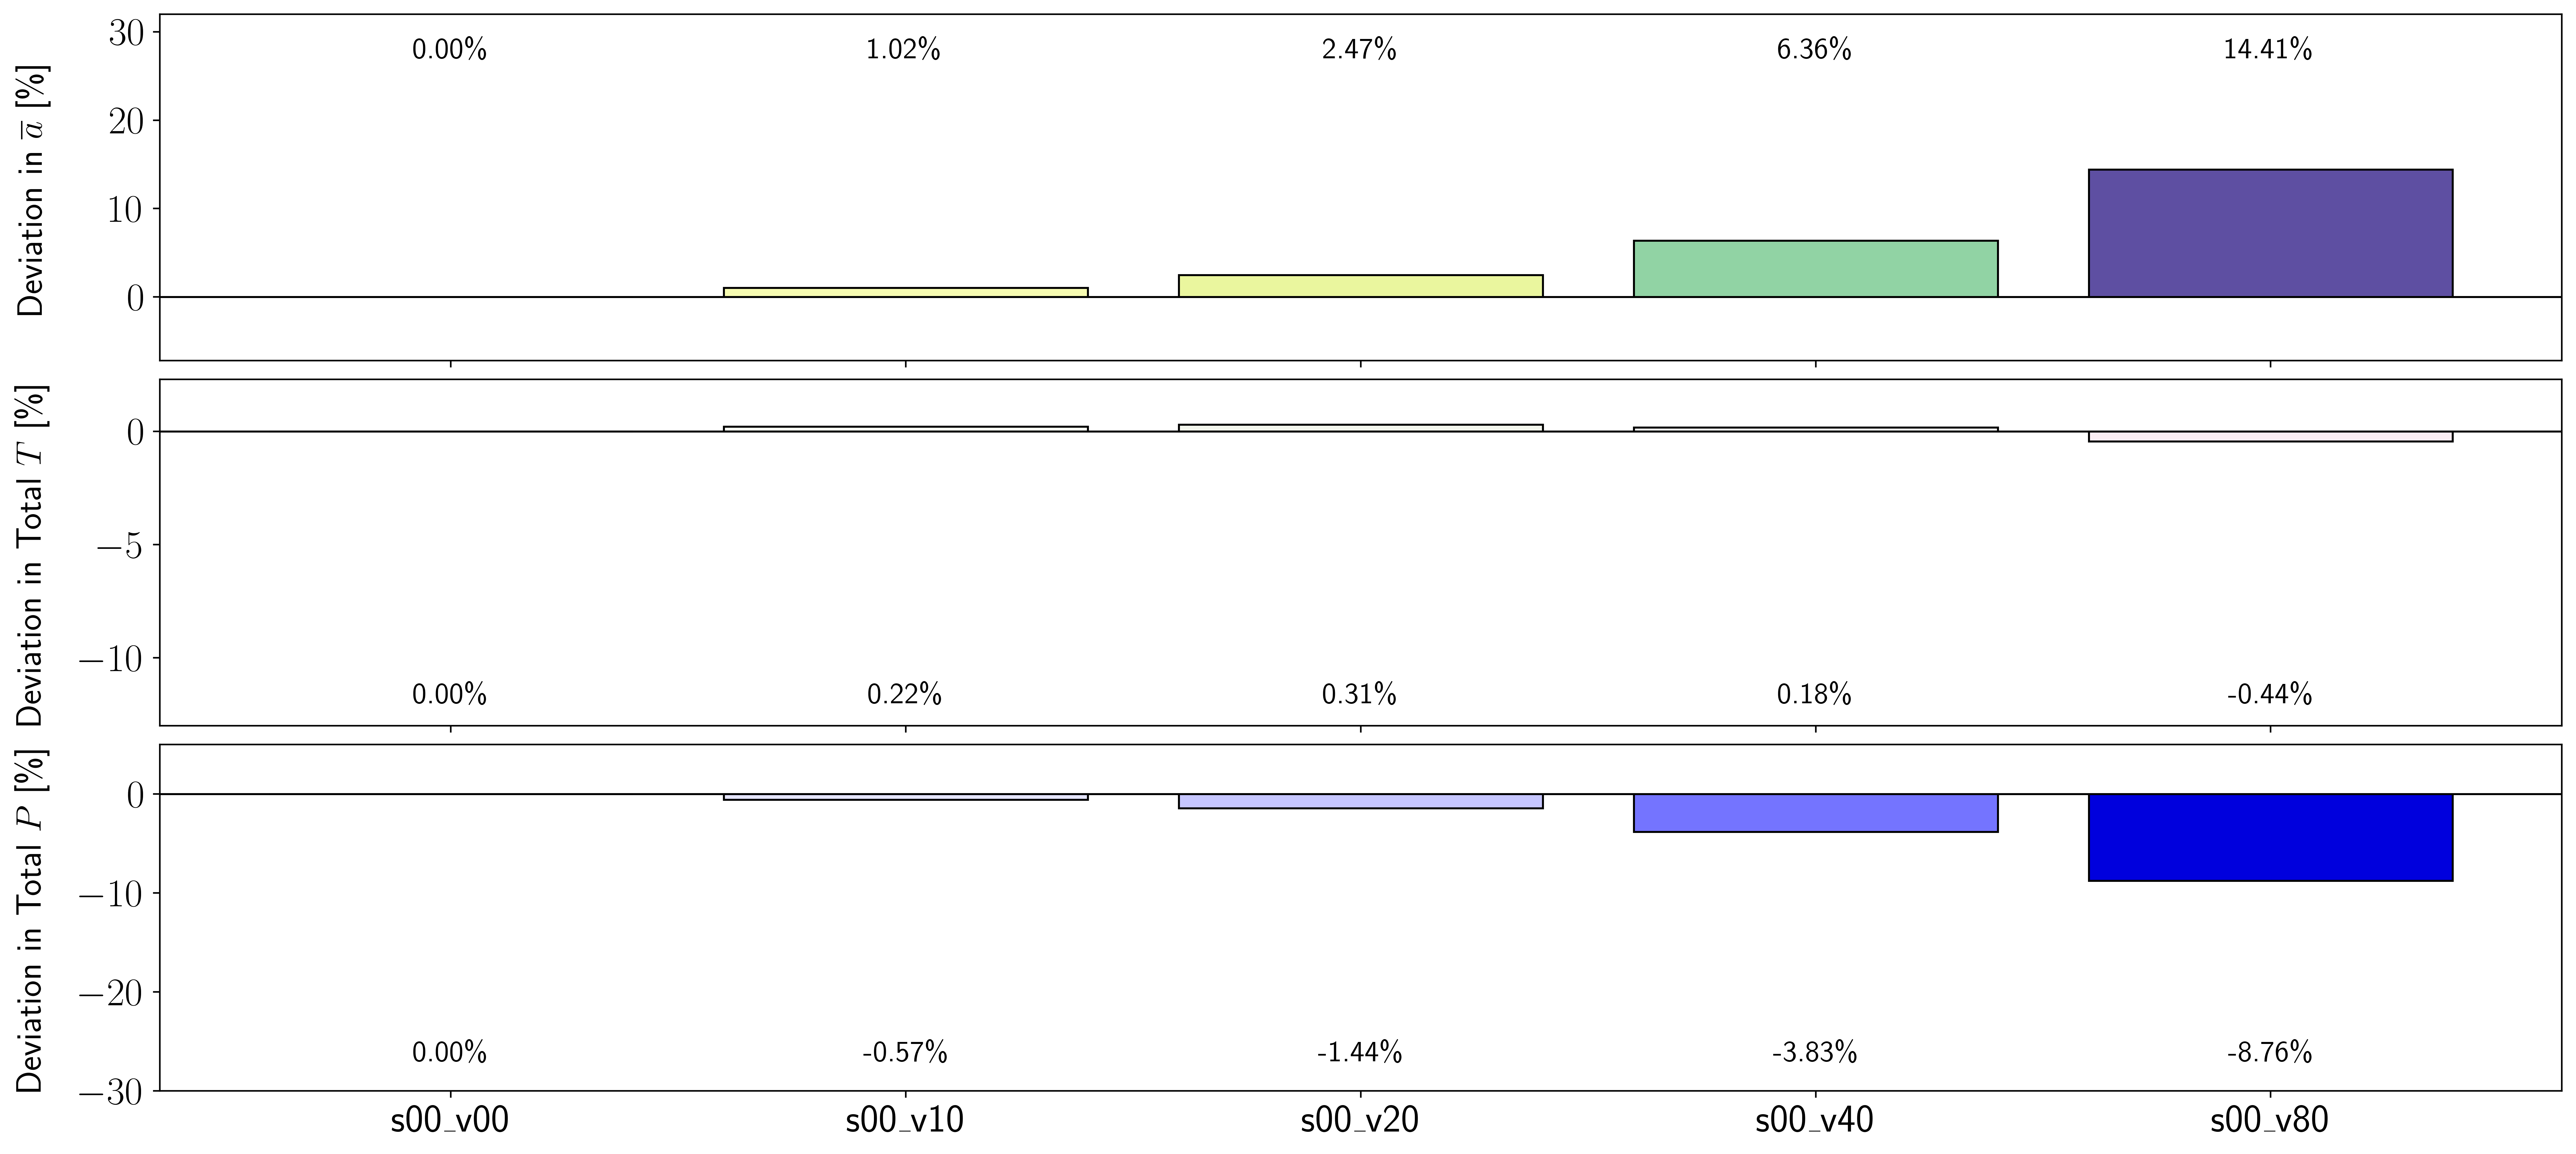

In [142]:
# casenames = [r's00_vn80', r's00_vn40', r's00_vn20', r's00_vn10', r's00_v00', r's00_v10', r's00_v20', r's00_v40', r's00_v80']
casenames = [r's00_v00', r's00_v10', r's00_v20', r's00_v40', r's00_v80']


width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout = True)
ax[0].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[1].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(0, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(casenames))

for count in range(len(casenames)):

    # induction
    ax[0].bar(ind[count], induction_dev[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    ax[0].set_ylabel(r'Deviation in ${\overline{a}}$ [\%]', fontsize=fontsize*0.75, labelpad=30)
    ax[0].text(ind[count], 27, f'{induction_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[0].set_ylim([-7.2,32])

    # thrust
    ax[1].bar(ind[count], thrust_dev[count], color=thr_cmap[count], edgecolor='black', alpha=alpha)
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize*0.75, labelpad=15)
    ax[1].text(ind[count], -12, f'{thrust_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[1].set_ylim([-13,2.3])

    # power
    ax[2].bar(ind[count], power_dev[count], color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(casenames)
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize*0.75, labelpad=15)
    ax[2].text(ind[count], -27, f'{power_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[2].set_ylim([-30,5])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

In [94]:
casenames = [
r's000000_vn402010',
r's000000_vn201005',
r's000000_vn100503',
r's000000_vn050251',
r's000000_v000000',
r's000000_v050251',
r's000000_v100503',
r's000000_v201005',
r's000000_v402010'
]

In [143]:
from MITRotor import BEM, IEA10MW, NoTipLoss, PrandtlTipLoss, KraghAerodynamics, ConstantInduction, NoTangentialInduction, MadsenMomentum, Madsen_Rotor_Momentum, BEMGeometry, ClassicalMomentum
import numpy as np

In [162]:
rotor = IEA10MW()
# veers = [8,4,2,1,0,1,2,4,8]
veers = [0,1,2,4,8]


# casenames = [r's000000_vn402010',
# r's000000_vn201005',
# r's000000_vn100503',
# r's000000_vn050251',
# r's000000_v000000',
# r's000000_v050251',
# r's000000_v100503',
# r's000000_v201005',
# r's000000_v402010']

casenames = [
r's000000_v000000',
r's000000_v050251',
r's000000_v100503',
r's000000_v201005',
r's000000_v402010']

mit_ind = np.zeros_like(casenames, dtype='float')
mit_cot  = np.zeros_like(casenames, dtype='float')
mit_cop  = np.zeros_like(casenames, dtype='float')
iters = np.zeros_like(casenames, dtype='float')

w = np.zeros_like(casenames, dtype='float')
cx = np.zeros_like(casenames, dtype='float')
sig_m = np.zeros_like(casenames, dtype='float')

from scipy.interpolate import RegularGridInterpolator

# bem = BEM(rotor=rotor, aerodynamic_model=KraghAerodynamics(), tiploss_model=PrandtlTipLoss(), momentum_model=ConstantInduction(a=0.2655), tangential_induction_model=DefaultTangentialInduction())
# bem = BEM(rotor=rotor, aerodynamic_model=KraghAerodynamics(), tiploss_model=PrandtlTipLoss(), momentum_model=ConstantInduction(a=0.2721), tangential_induction_model=DefaultTangentialInduction())

# bem = BEM(rotor=rotor, aerodynamic_model=KraghAerodynamics(), tiploss_model=PrandtlTipLoss(), momentum_model=MadsenMomentum(averaging='annulus'), tangential_induction_model=DefaultTangentialInduction())
# bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=26,Ntheta=158), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_Rotor_Momentum(), tangential_induction_model=DefaultTangentialInduction())

ind_ubar = [31,32,33,34,35]

for count in range(len(casenames)):

    # bem = BEM(rotor=rotor, aerodynamic_model=KraghAerodynamics(), tiploss_model=PrandtlTipLoss(), momentum_model=ConstantInduction(a=induction[count]), tangential_induction_model=DefaultTangentialInduction())
    # bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=26,Ntheta=158), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_Rotor_Momentum(veer=veers[count]), tangential_induction_model=NoTangentialInduction())
    bem = BEM(rotor=rotor, aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_Rotor_Momentum(veer=veers[count]), tangential_induction_model=NoTangentialInduction())

    # bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=26,Ntheta=158), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ClassicalMomentum(), tangential_induction_model=NoTangentialInduction())

    # u_func = interp1d(data[casenames[count]][:,0],data[casenames[count]][:,1])
    # v_func = interp1d(data[casenames[count]][:,0],data[casenames[count]][:,2])

    # u = u_func(z)
    # v = v_func(z)

    # wdir = np.atan2(v,u)

    # U = (u**2 + v**2)**(1/2)

    # pitch, tsr, yaw = 0, 9, 0
    # pitch, tsr, yaw = 0, wrf_tsr[ind_ubar[count]]-0.65, 0

    tsr = wrf_tsr[count] * rotor.R / wrfles_bem[count]['radius']
    # tsr = wrf_tsr[count]


    t = np.linspace(0,2*np.pi,nSections)
    r = wrfles_bem[0]['rOverR']

    interpU = RegularGridInterpolator(
    (r, t), U_loc[:,:,ind_ubar[count]], bounds_error=False, fill_value=None
    )

    interpW = RegularGridInterpolator(
    (r, t), dir_loc[:,:,ind_ubar[count]], bounds_error=False, fill_value=None
    )

    t_new = np.linspace(0,2*np.pi,20)
    r_new = np.linspace(0,1,10)

    R_new, T_new = np.meshgrid(r_new, t_new, indexing='ij')

    points = np.column_stack((R_new.ravel(), T_new.ravel()))  # shape (Nr*Nt, 2)
    U_interp_flat = interpU(points)
    W_interp_flat = interpW(points)
    U_interp = U_interp_flat.reshape(R_new.shape)
    W_interp = W_interp_flat.reshape(R_new.shape)

    # sol = bem(0, tsr, 0, U = U_loc[:,:,ind_ubar[count]], wdir=dir_loc[:,:,ind_ubar[count]],veer=veers[count])

    # sol = bem(0, tsr-0.352, 0, U = U_interp, wdir=W_interp,veer=veers[count])
    sol = bem(0, tsr, 0, U = U_interp, wdir=W_interp,veer=veers[count])


    # sol = bem(pitch, tsr, yaw, veer=veers[count])

    # sol = bem(pitch, tsr, yaw, wdir=wdir, veer=veers[count])


    mit_cot[count] = sol.Ct()
    mit_cop[count] = sol.Cp()
    mit_ind[count] = sol.a()
    iters[count] = sol.niter
    w[count] = sol.W()
    cx[count] = sol.Cx()
    # sig_m[count] = sol.aero_props.solidity



In [107]:
iters

array([3., 3., 3., 5., 6.])

In [98]:
tsr

np.float64(9.009159200489522)

In [91]:
U_loc[:,:,31]

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(26, 158))

In [152]:
from wrf_io import postproc

power_dev     = postproc.per_error(mit_cop, mit_cop[0])
thrust_dev    = postproc.per_error(mit_cot, mit_cot[0])
induction_dev = postproc.per_error(mit_ind, mit_ind[0])

In [153]:
import matplotlib.colors as mcolors

n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-15, vmax=15)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-6, vmax=6)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-13, vmax=13)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in induction_dev]  # Map power to discrete colors

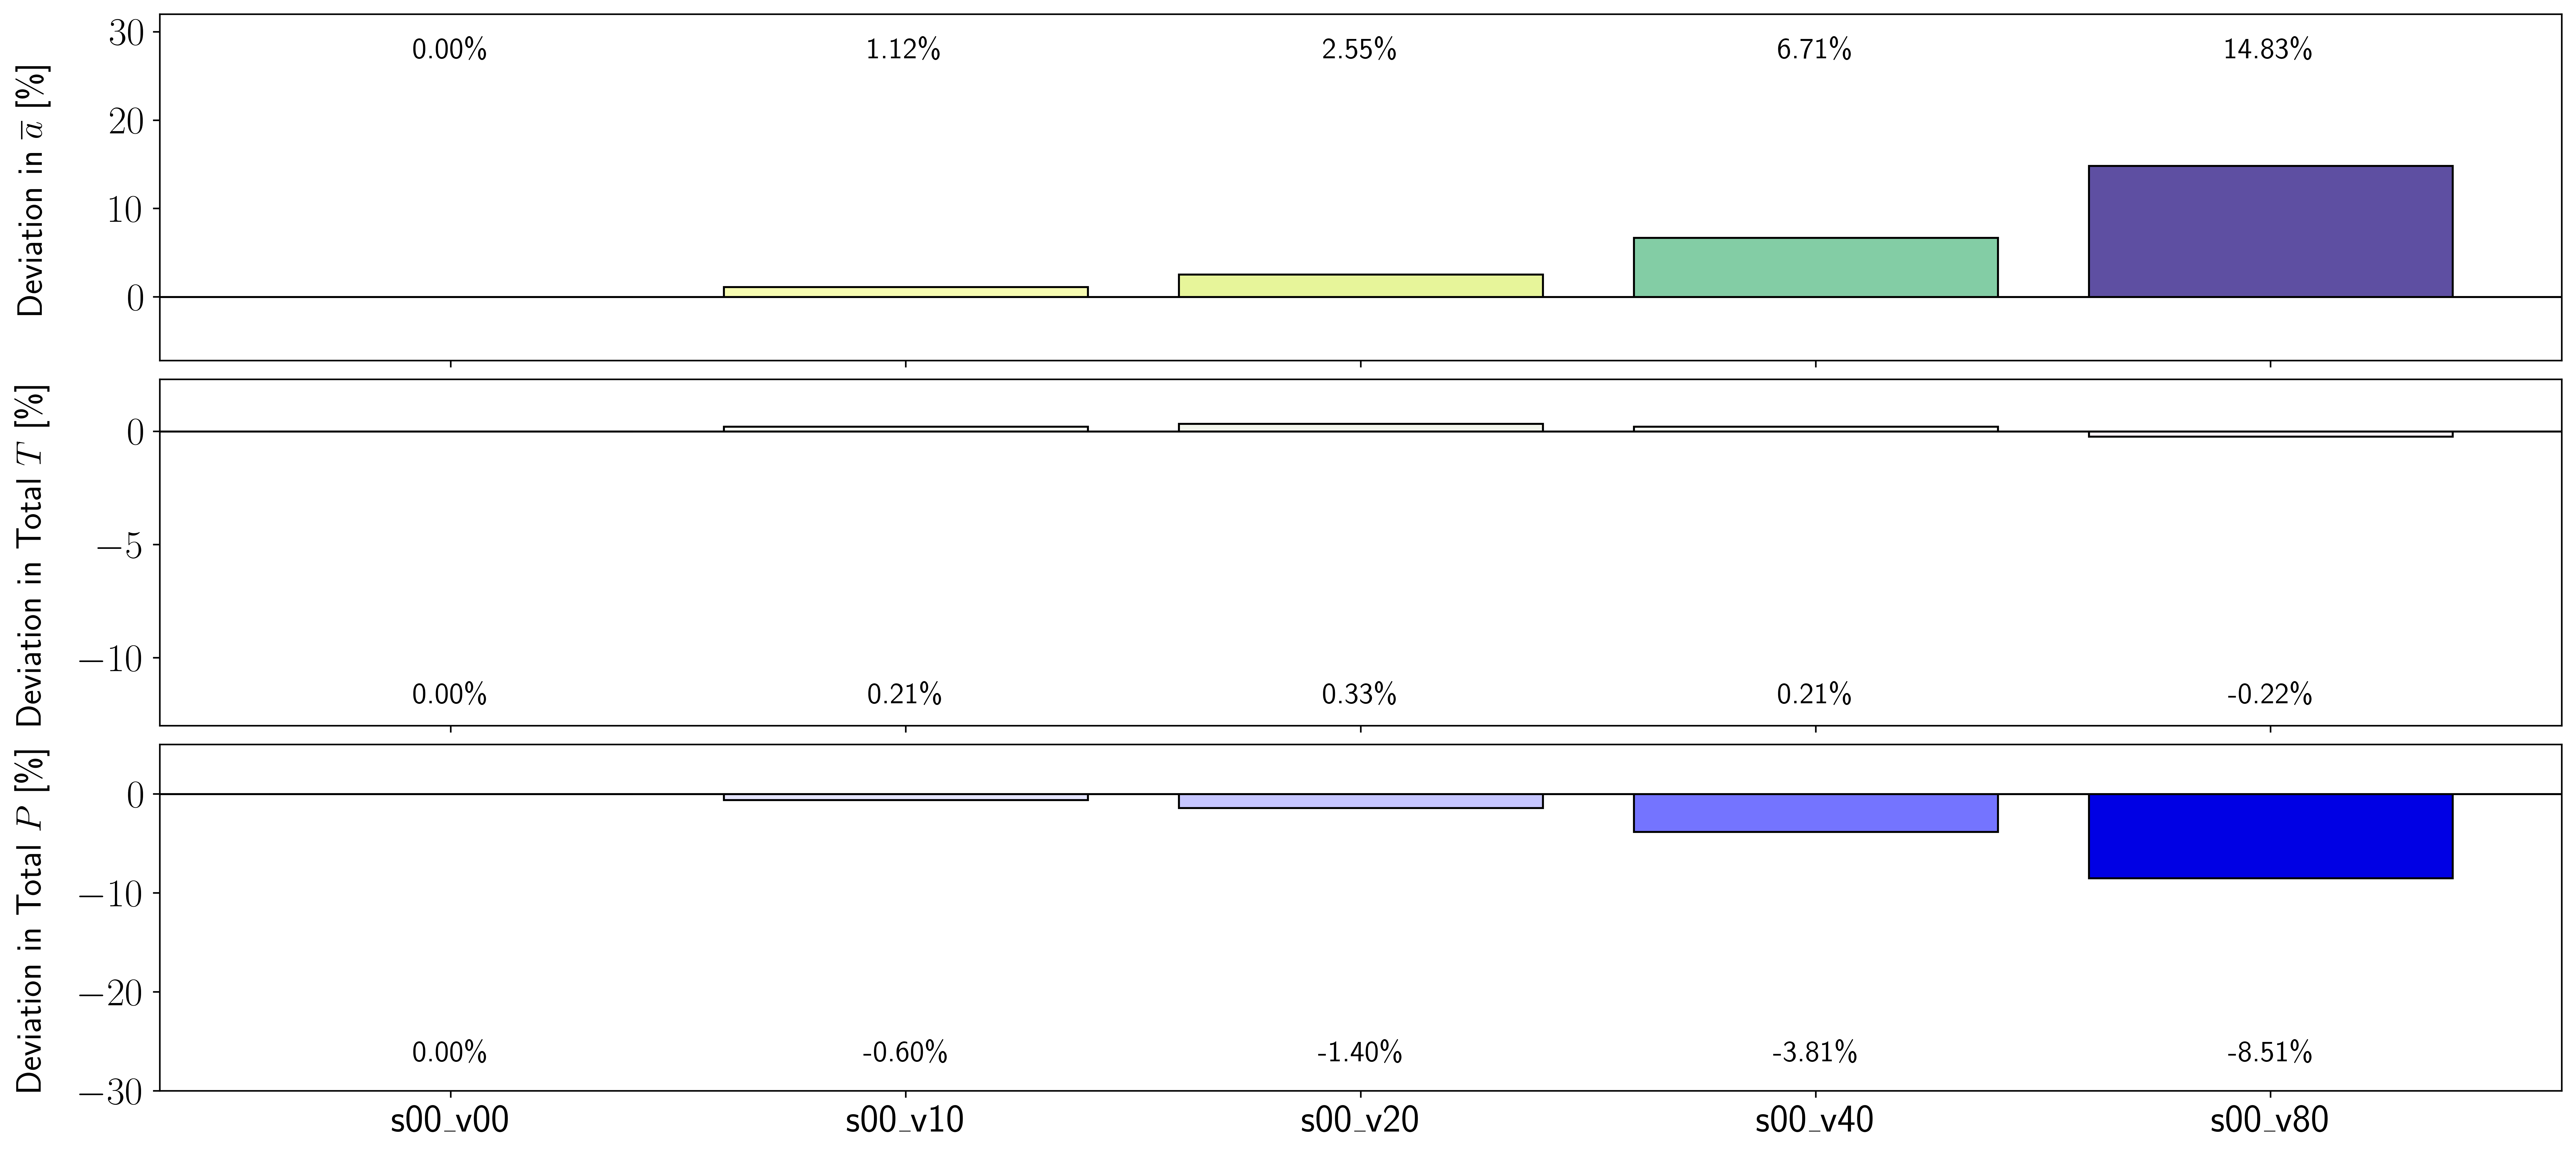

In [154]:
# casenames = [r's00_vn80', r's00_vn40', r's00_vn20', r's00_vn10', r's00_v00', r's00_v10', r's00_v20', r's00_v40', r's00_v80']
casenames = [r's00_v00', r's00_v10', r's00_v20', r's00_v40', r's00_v80']



width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout = True)
ax[0].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[1].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(0, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(casenames))

for count in range(len(casenames)):

    # induction
    ax[0].bar(ind[count], induction_dev[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    ax[0].set_ylabel(r'Deviation in ${\overline{a}}$ [\%]', fontsize=fontsize*0.75, labelpad=30)
    ax[0].text(ind[count], 27, f'{induction_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[0].set_ylim([-7.2,32])

    # thrust
    ax[1].bar(ind[count], thrust_dev[count], color=thr_cmap[count], edgecolor='black', alpha=alpha)
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize*0.75, labelpad=15)
    ax[1].text(ind[count], -12, f'{thrust_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[1].set_ylim([-13,2.3])

    # power
    ax[2].bar(ind[count], power_dev[count], color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(casenames)
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize*0.75, labelpad=15)
    ax[2].text(ind[count], -27, f'{power_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[2].set_ylim([-30,5])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

In [26]:
len(mit_ind)

9

Text(0.5, 0, '$a$ [-]')

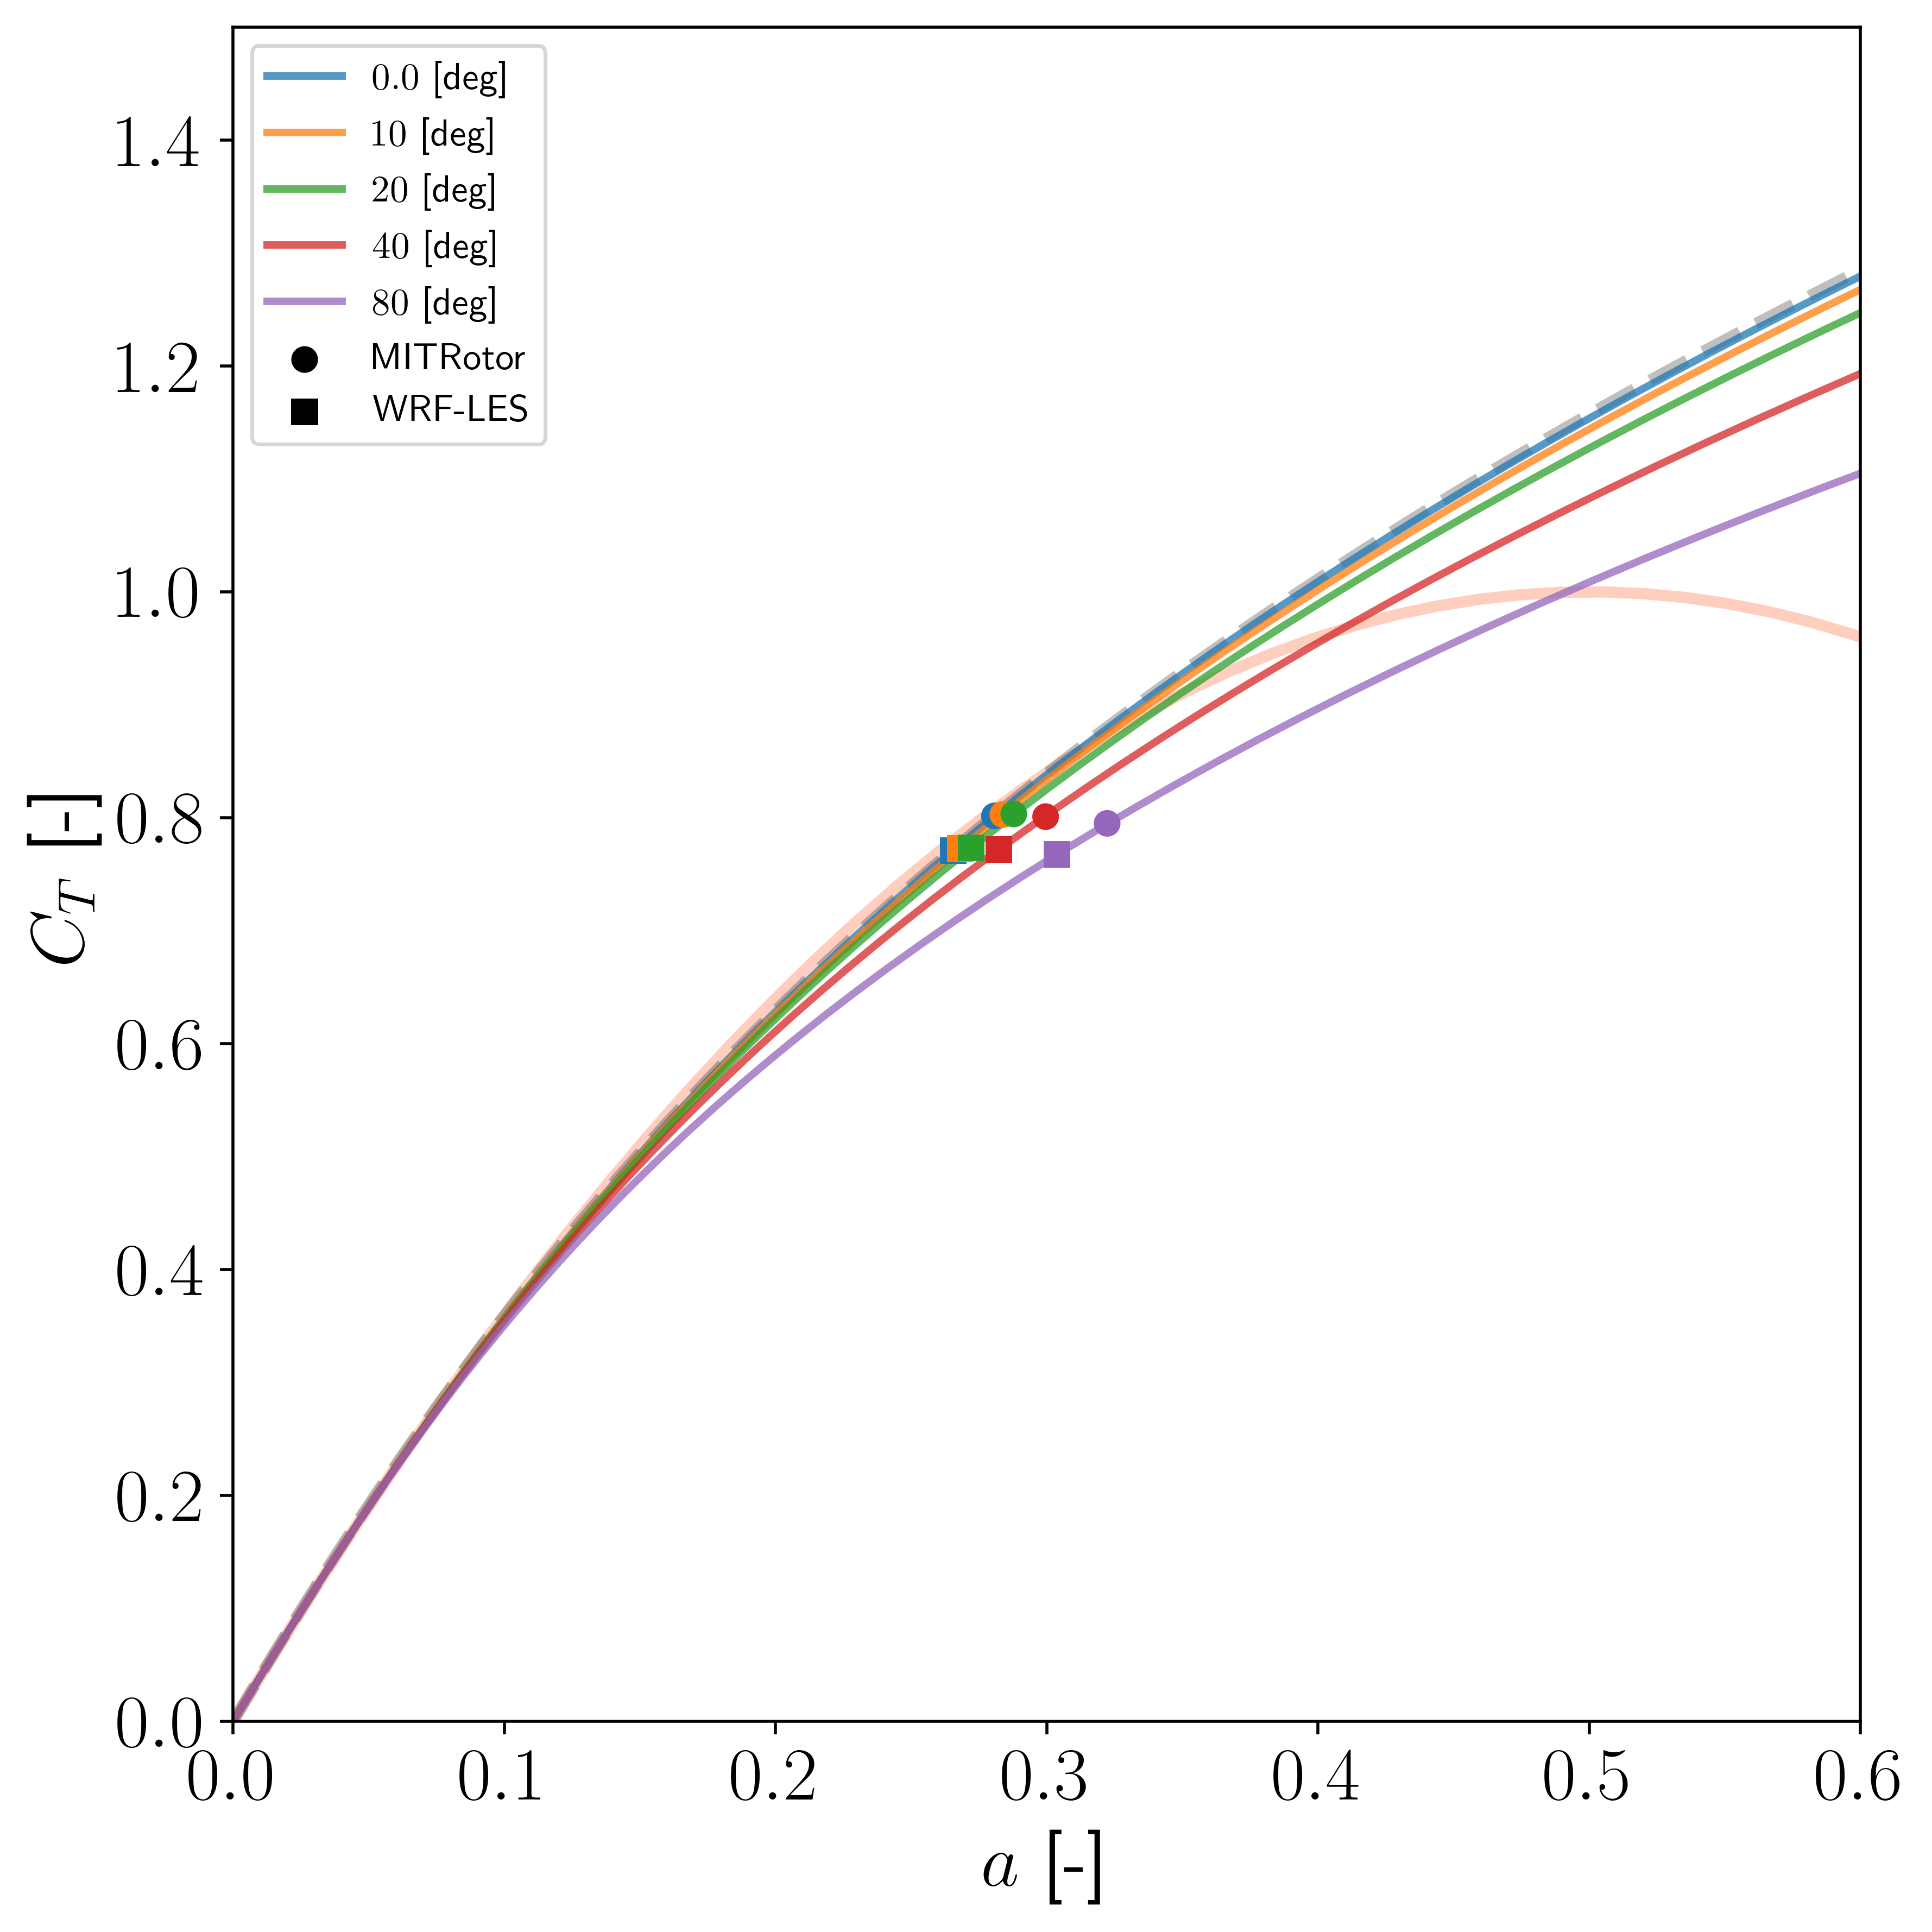

In [163]:
colors = sns.color_palette("tab10", 5)
colors = colors + colors[::-1]

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0.0$ [deg]')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$10$ [deg]')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$20$ [deg]')
ax.plot(y_fit_v40, x_fit_v40, color=colors[3],linewidth=2,zorder=2,alpha=0.75,label='$40$ [deg]')
ax.plot(y_fit_v80, x_fit_v80, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$80$ [deg]')

# for i in range(len(mit_ind)):
#     mesh = ax.scatter(mit_ind[i], mit_cot[i], s=50, edgecolor='none',color=colors[i],zorder=3)

mesh = ax.scatter(mit_ind[0], mit_cot[0], s=50, edgecolor='none',color=colors[0],zorder=3)
mesh = ax.scatter(mit_ind[1], mit_cot[1], s=50, edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(mit_ind[2], mit_cot[2], s=50, edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(mit_ind[3], mit_cot[3], s=50, edgecolor='none',color=colors[3],zorder=3)
mesh = ax.scatter(mit_ind[4], mit_cot[4], s=50, edgecolor='none',color=colors[4],zorder=3)
# mesh = ax.scatter(mit_ind[5], mit_cot[5], s=50, edgecolor='none',color=colors[1],zorder=3)
# mesh = ax.scatter(mit_ind[6], mit_cot[6], s=50, edgecolor='none',color=colors[2],zorder=3)
# mesh = ax.scatter(mit_ind[7], mit_cot[7], s=50, edgecolor='none',color=colors[3],zorder=3)
# mesh = ax.scatter(mit_ind[8], mit_cot[8], s=50, edgecolor='none',color=colors[4],zorder=3)

for i in range(len(indices_00)):
    mesh = ax.scatter(ind_rotor[indices_00[i]], ct_rotor[indices_00[i]], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    mesh = ax.scatter(ind_rotor[indices_10[i]], ct_rotor[indices_10[i]], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    mesh = ax.scatter(ind_rotor[indices_20[i]], ct_rotor[indices_20[i]], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    mesh = ax.scatter(ind_rotor[indices_40[i]], ct_rotor[indices_40[i]], s=50, marker='s', edgecolor='none',color=colors[3],zorder=3)

for i in range(len(indices_80)):
    mesh = ax.scatter(ind_rotor[indices_80[i]], ct_rotor[indices_80[i]], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',zorder=3,label='MITRotor')
mesh = ax.scatter(-5, -5, s=50, marker='s', edgecolor='none',color='k',zorder=3,label='WRF-LES')

ax.legend()

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.5])

# ax.set_xlim([0.25,0.31])
# ax.set_ylim([0.73,0.79])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

Text(0.5, 0, '$a$ [-]')

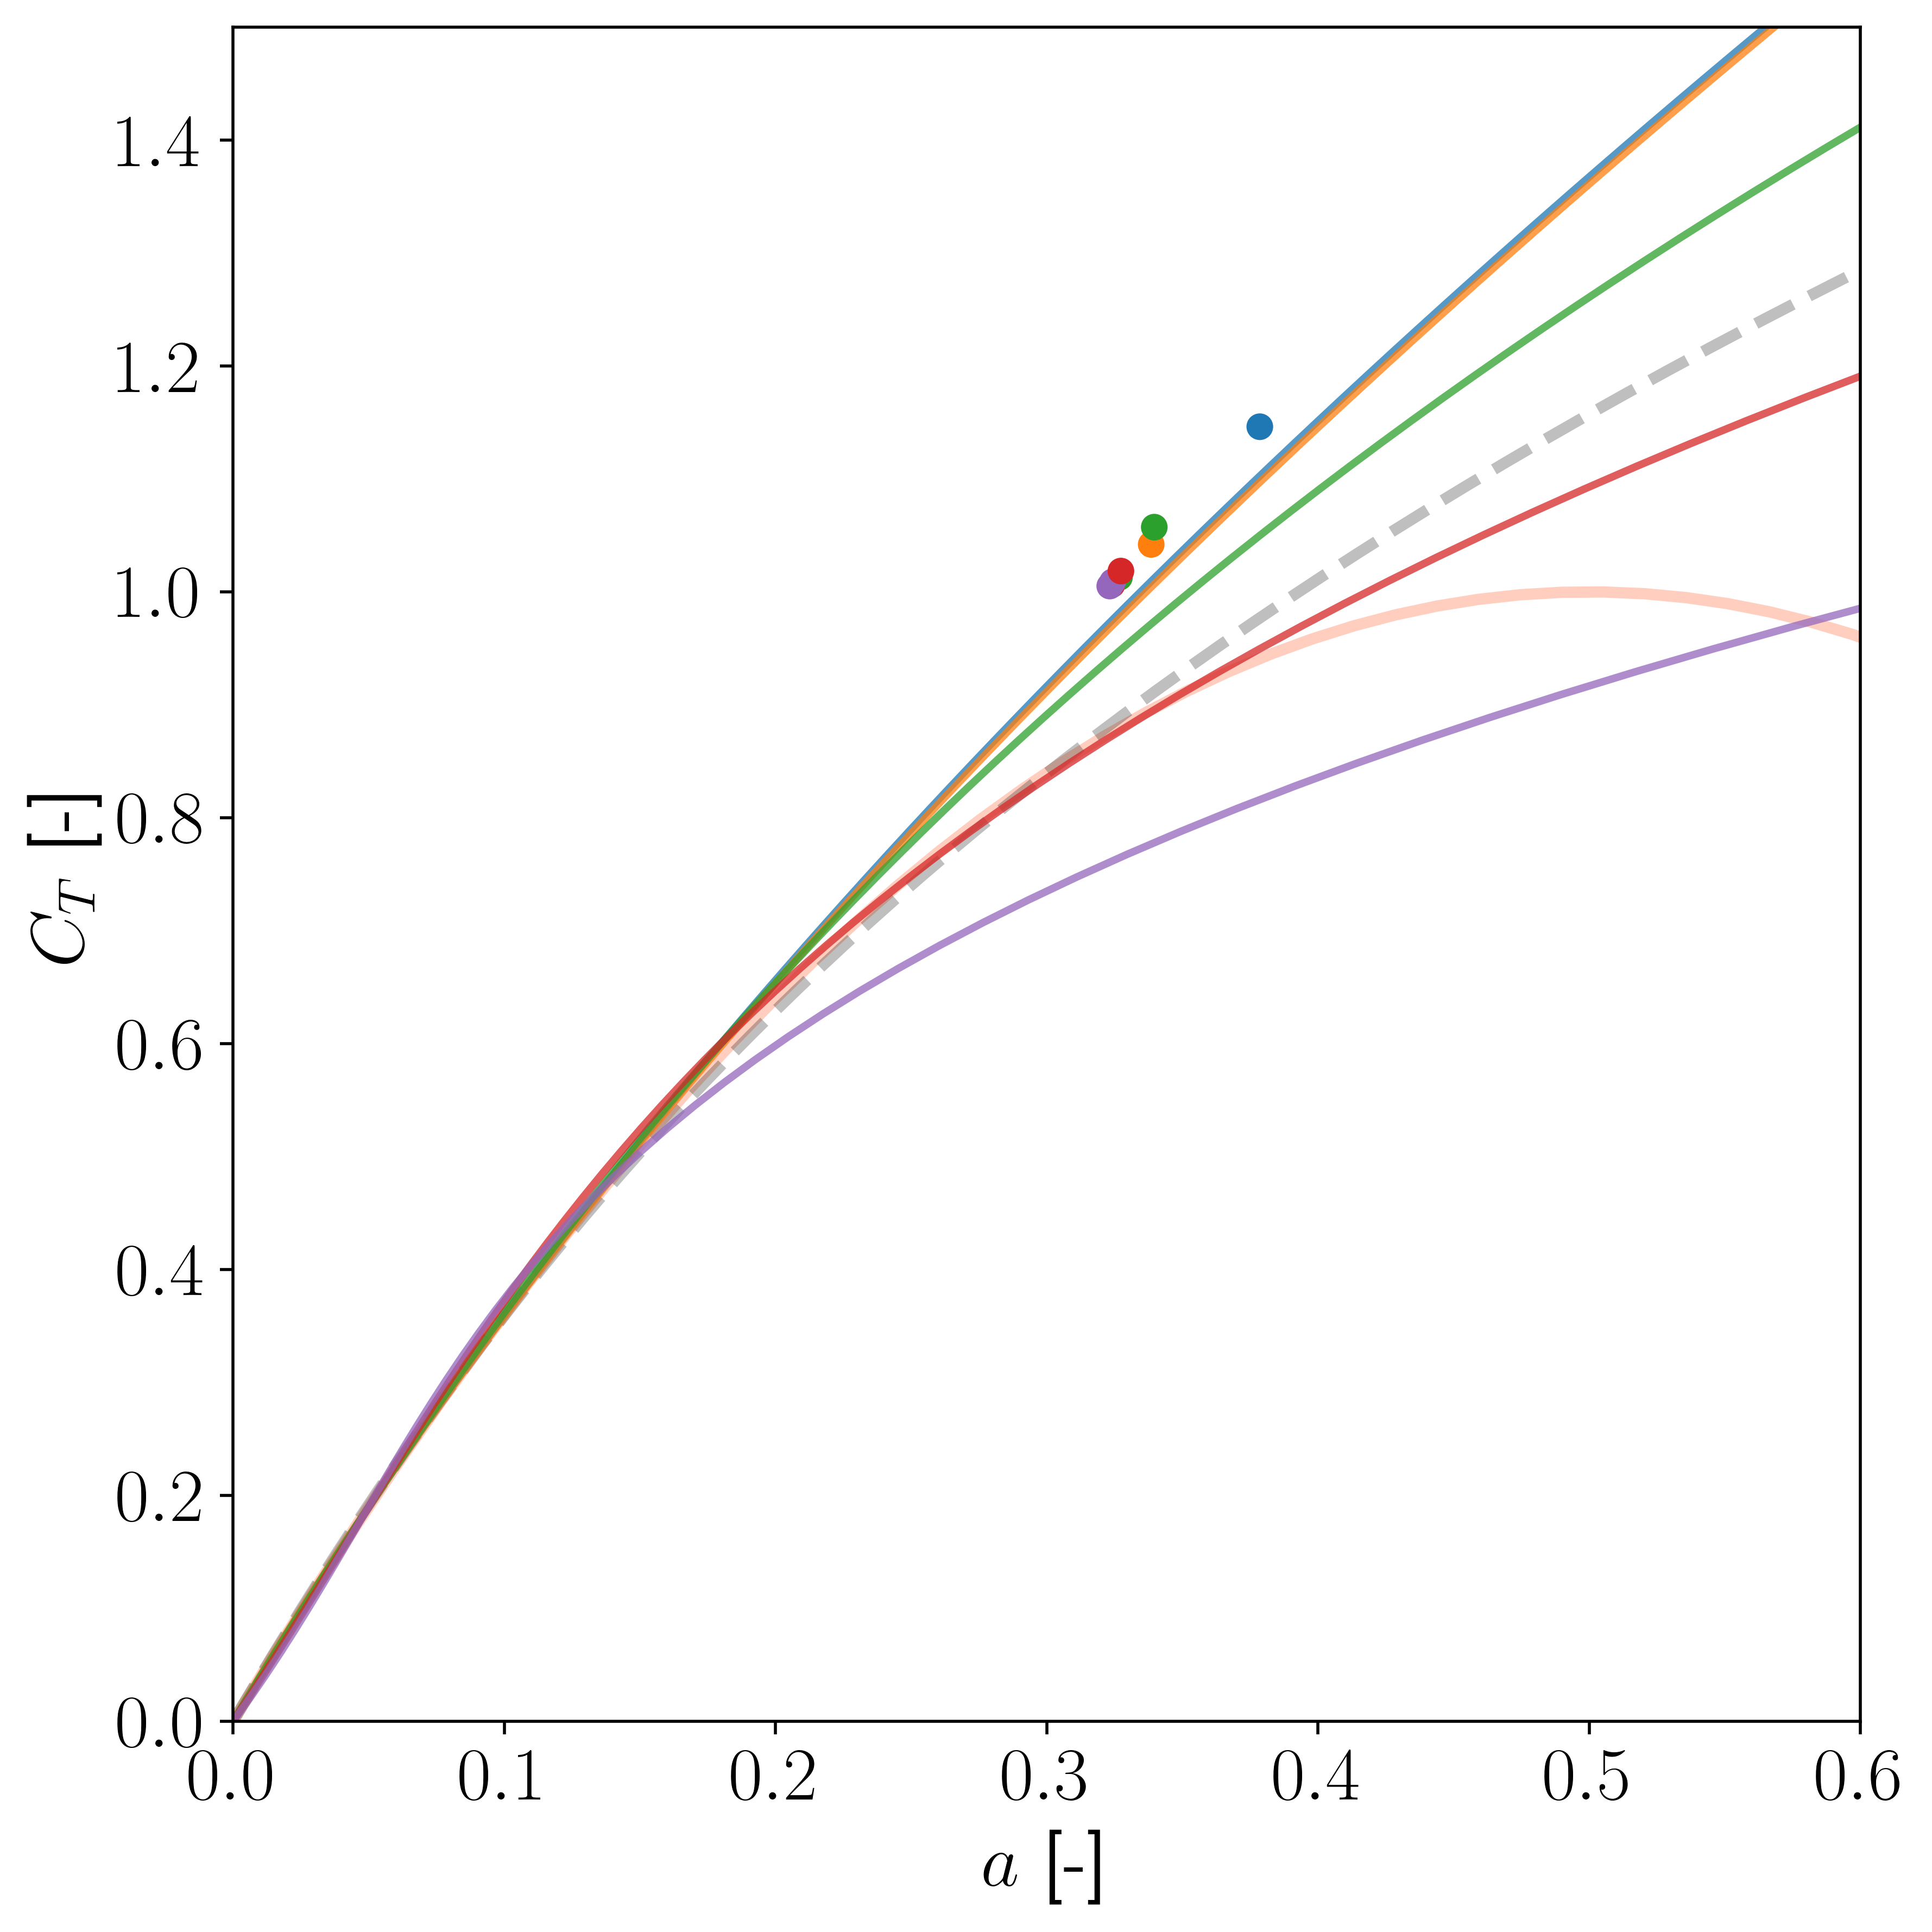

In [89]:
colors = sns.color_palette("tab10", 5)
colors = colors + colors[::-1]

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$|0.0|$ [deg]')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$|10|$ [deg]')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$|20|$ [deg]')
ax.plot(y_fit_v40, x_fit_v40, color=colors[3],linewidth=2,zorder=2,alpha=0.75,label='$|40|$ [deg]')
ax.plot(y_fit_v80, x_fit_v80, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$|80|$ [deg]')

for i in range(len(mit_ind)):
    # mesh = ax.scatter(ind[i], ct[i], s=50, edgecolor='none',color=colors[i],zorder=3)
    mesh = ax.scatter(mit_ind[i], mit_cot[i], s=50, edgecolor='none',color=colors[i],zorder=3)


ax.set_xlim([0,0.6])
ax.set_ylim([0,1.5])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

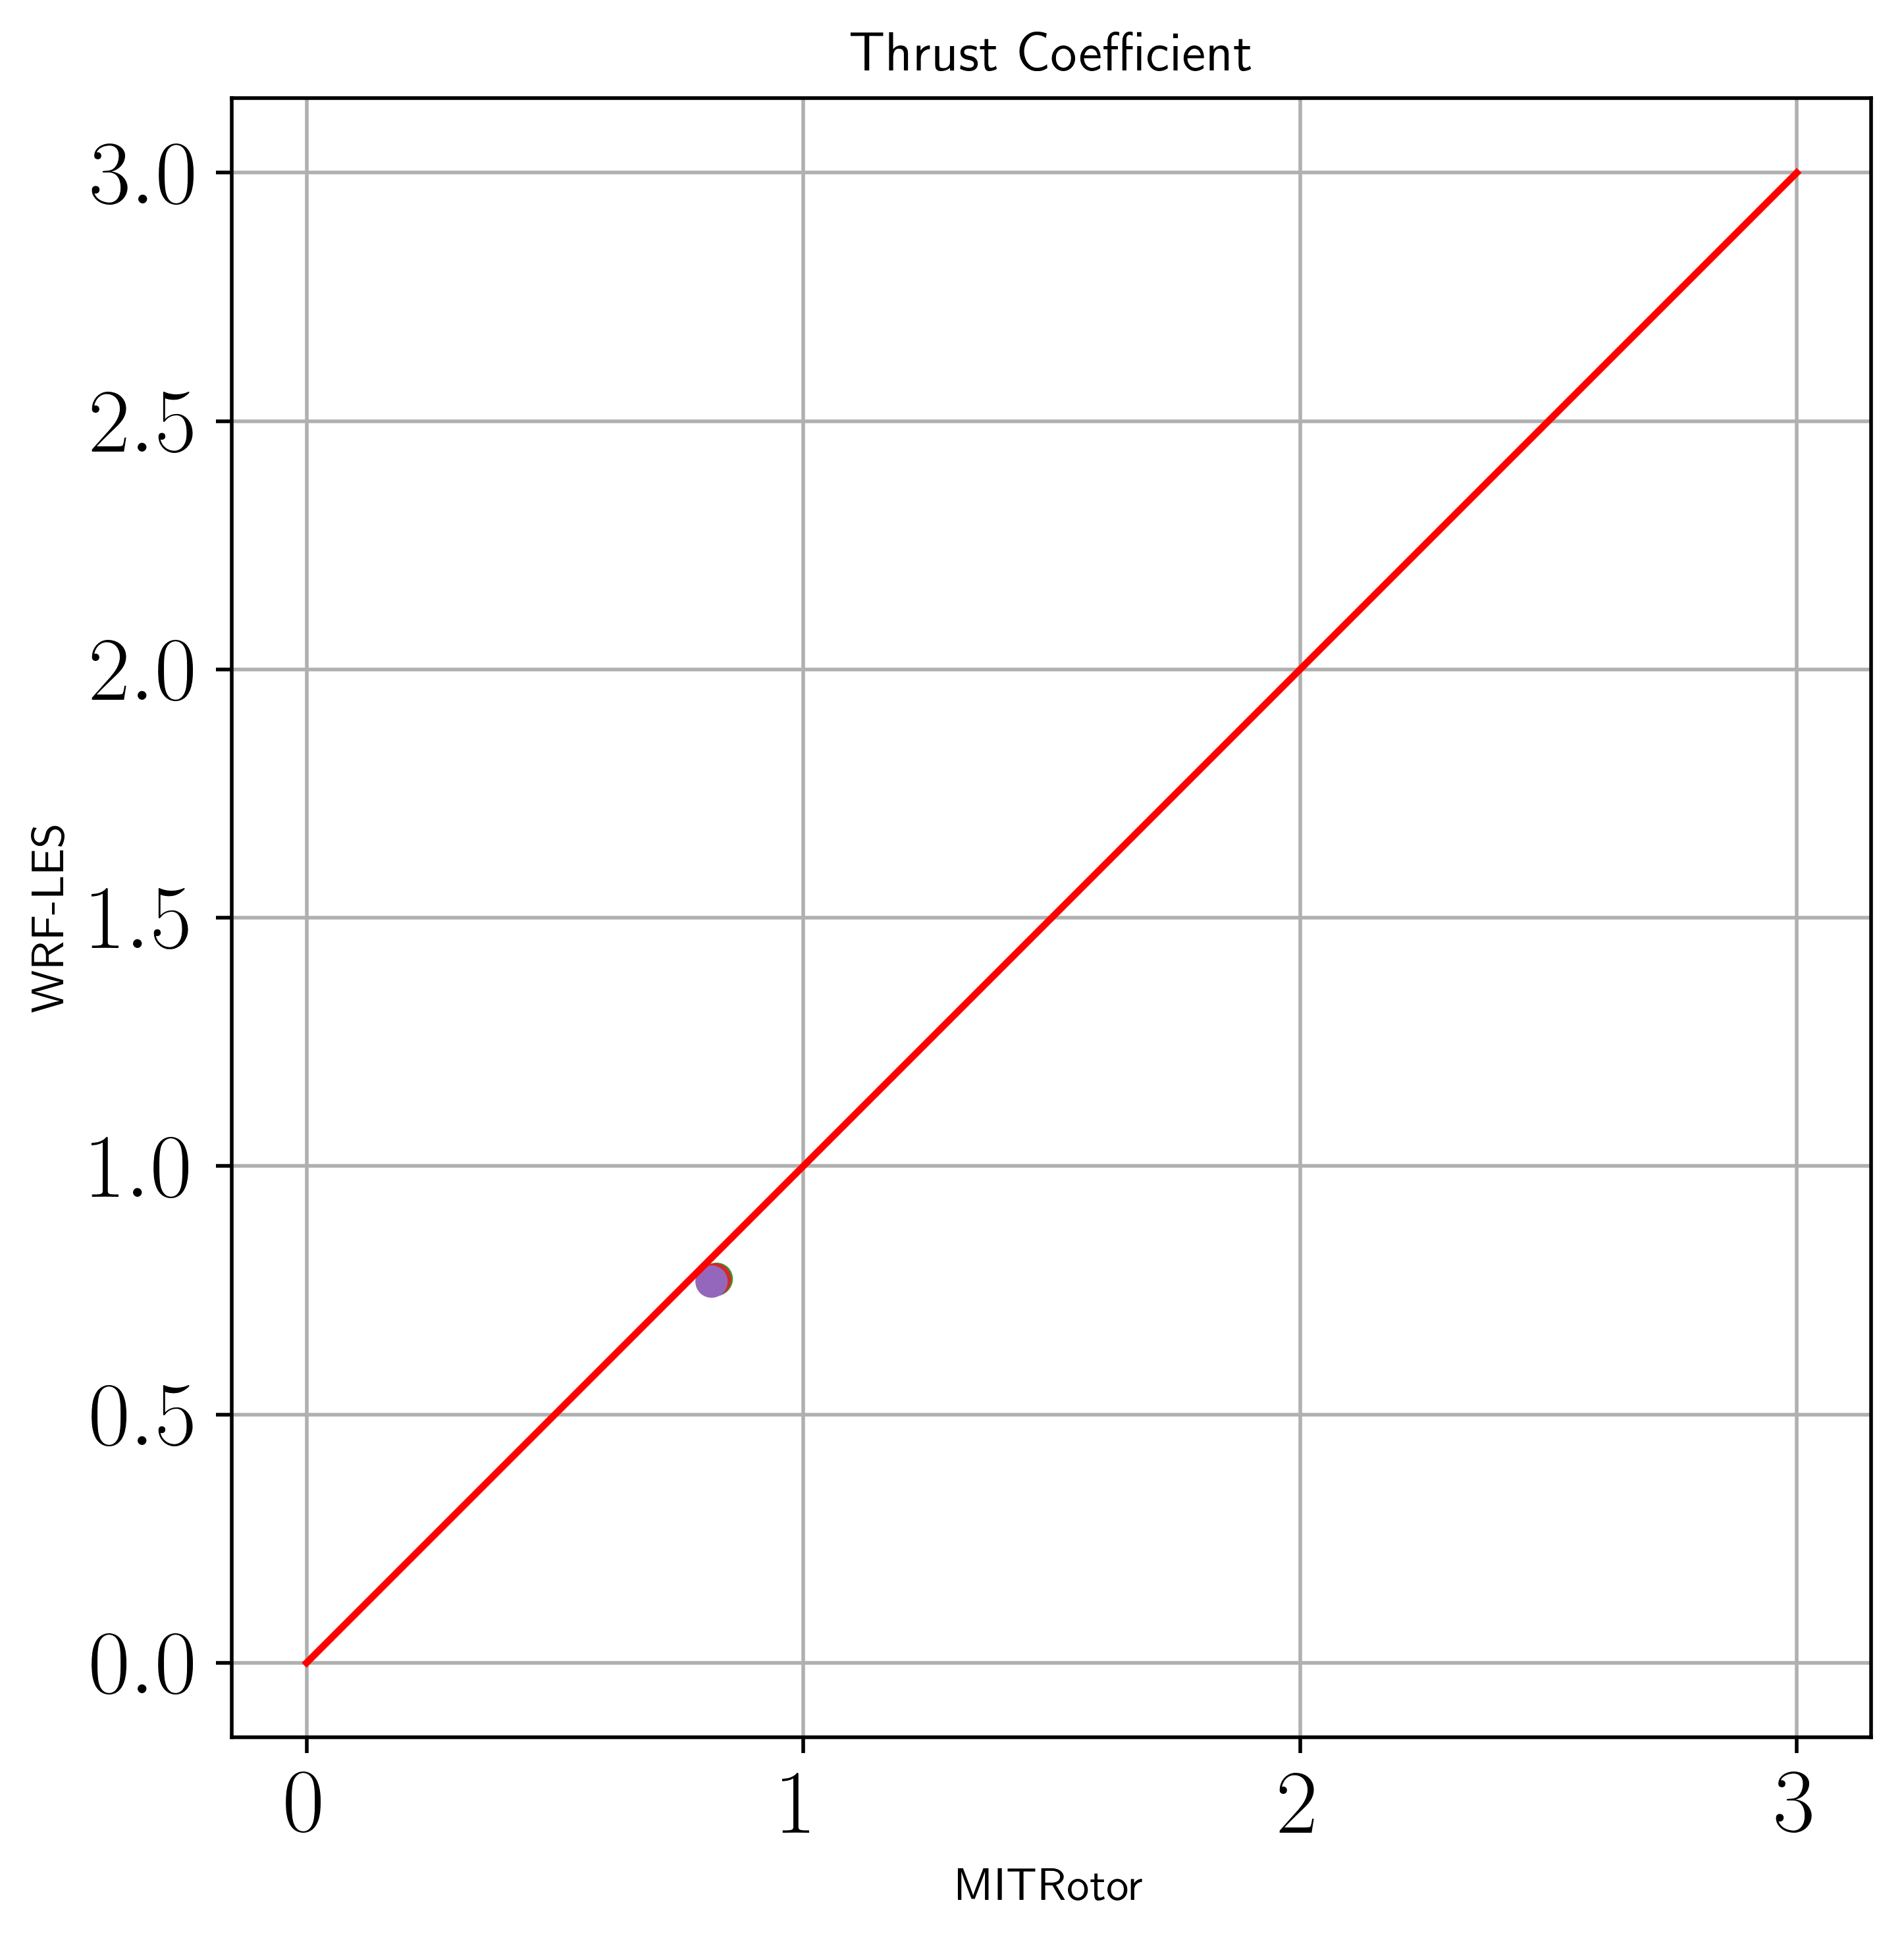

In [252]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_cot)):
    ax.scatter(mit_cot[i], ct_rotor[ind_ubar[i]], s=50, edgecolor='none', color=colors[i])
# ax.scatter(mit_cot[4], ct_rotor[indices_00], s=50, edgecolor='none')

ax.plot([0,3],[0,3],color='r')

# ax.set_xlim([0.70,1.04])
# ax.set_ylim([0.70,1.04])
ax.set_aspect('equal')

plt.title(f"Thrust Coefficient")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

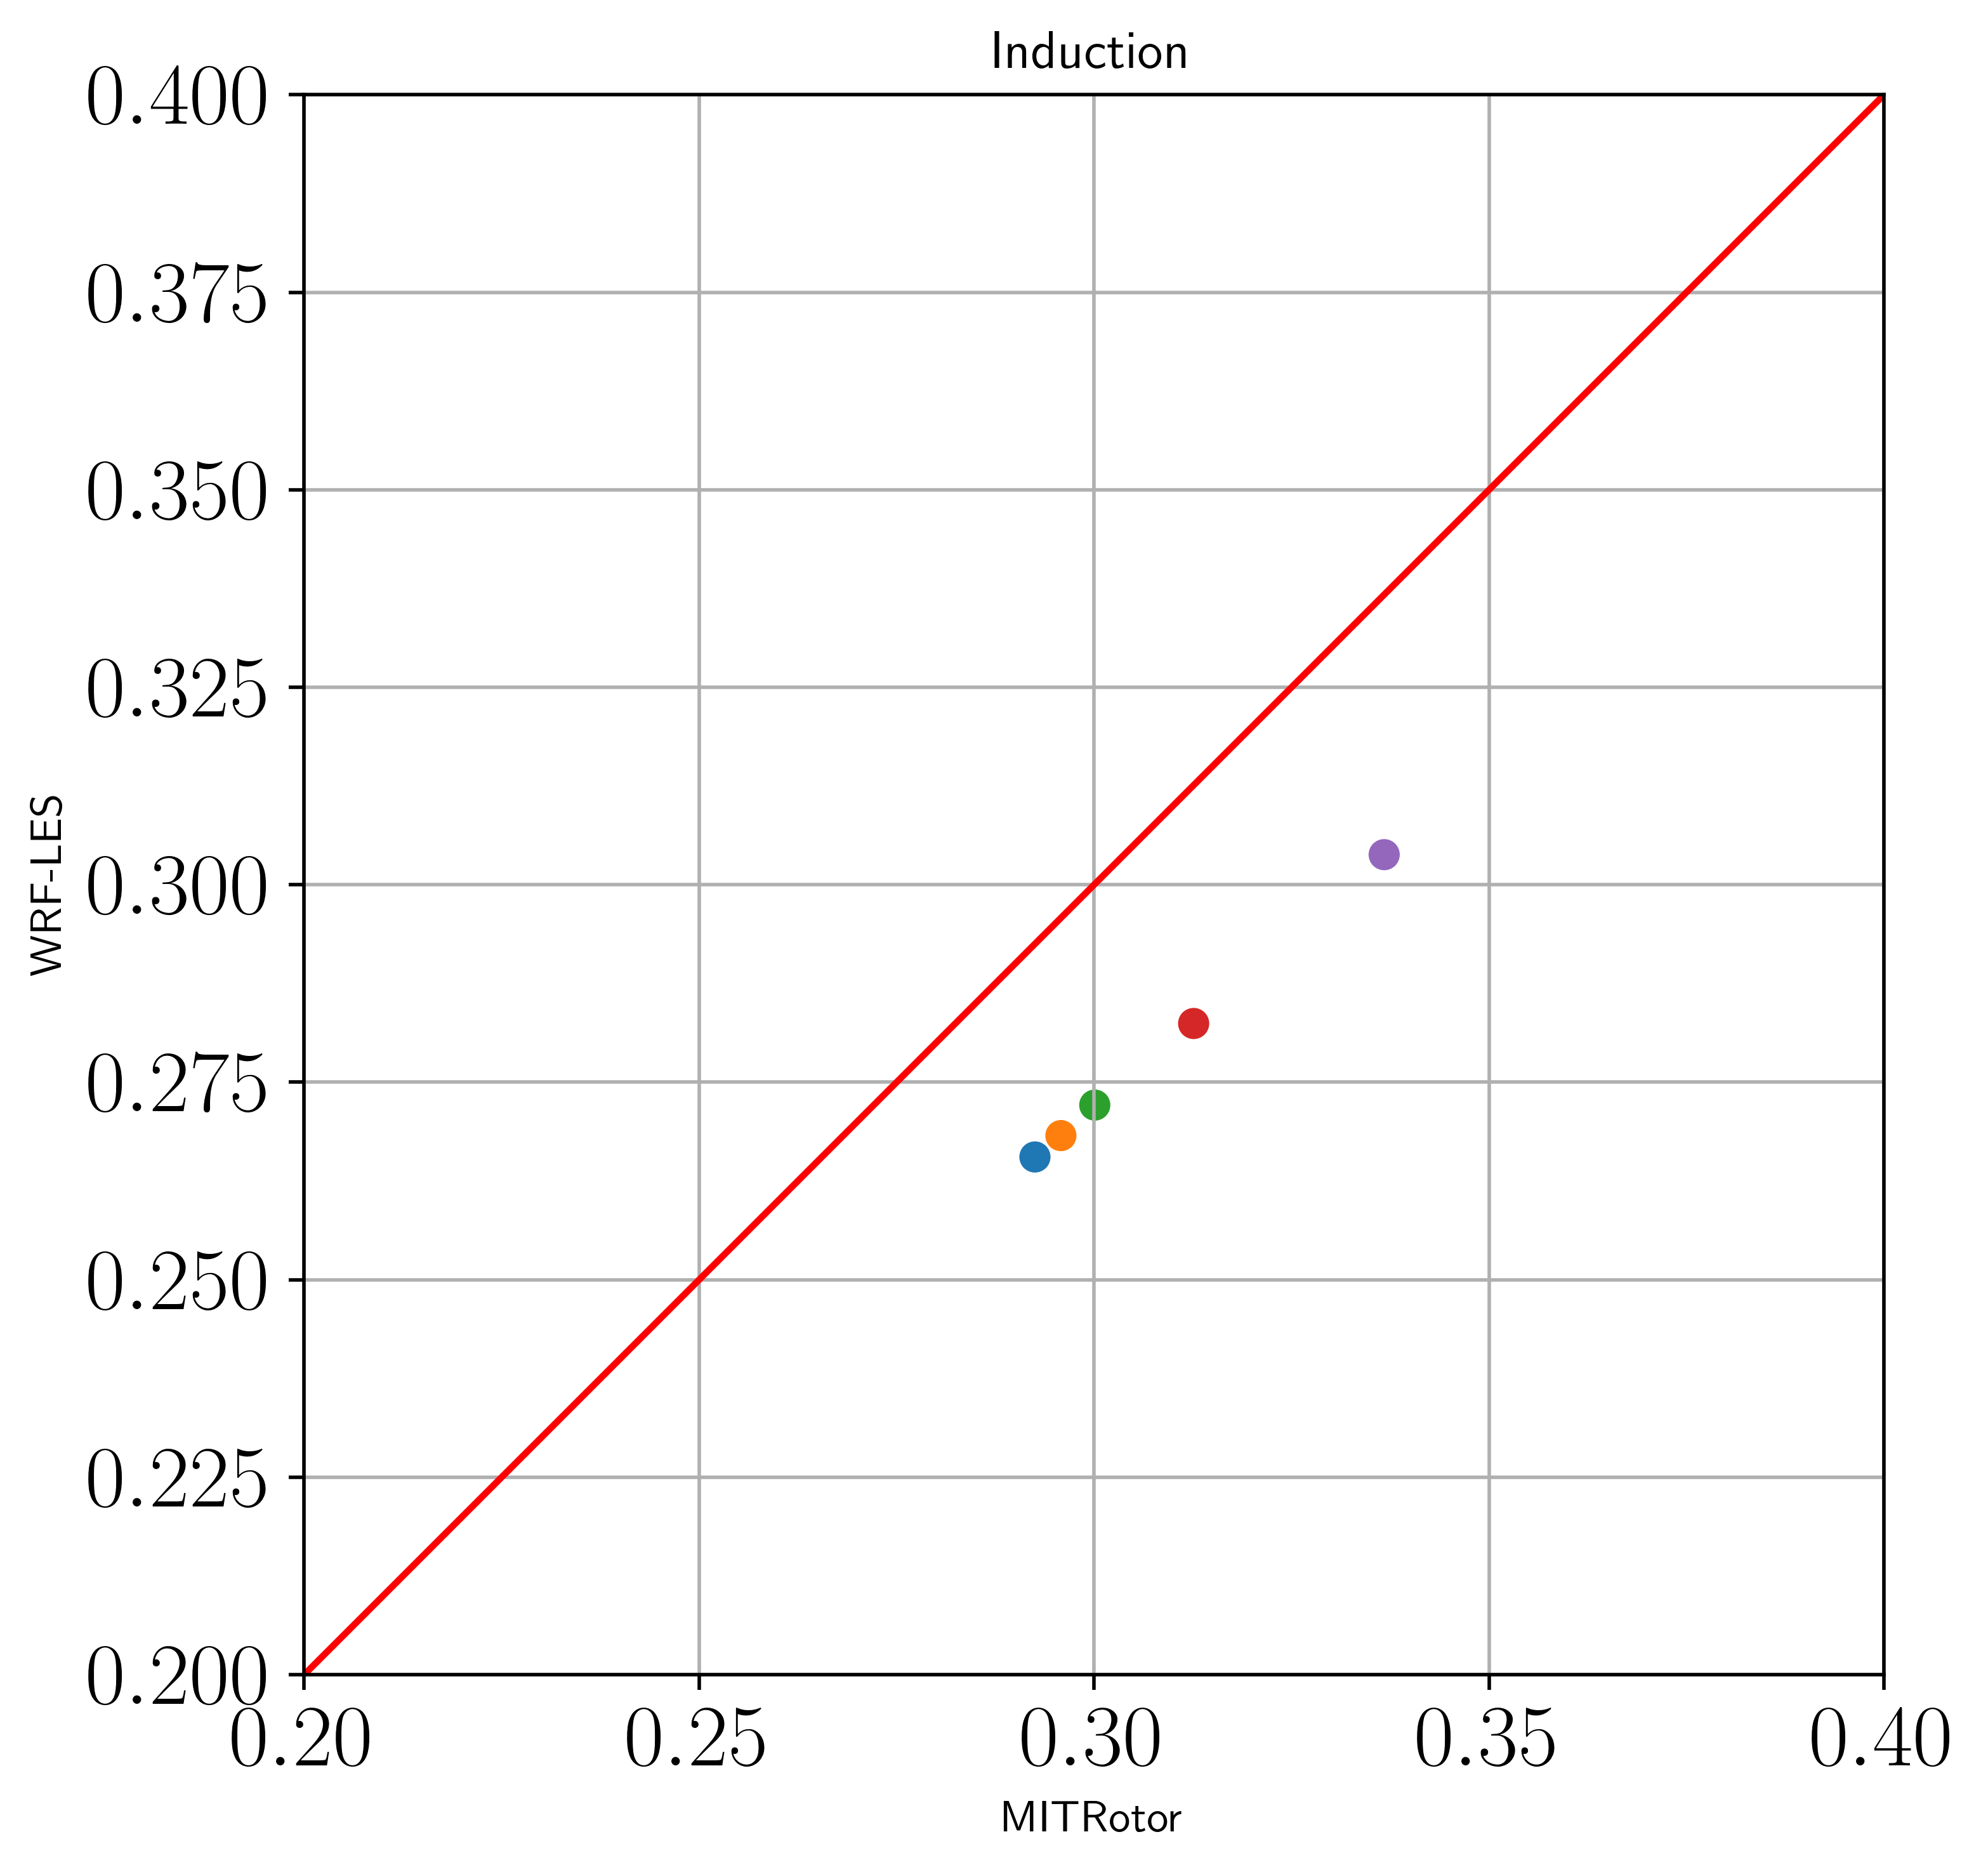

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_ind)):
    ax.scatter(mit_ind[i], ind_rotor[ind_ubar[i]], s=50, edgecolor='none', color=colors[i])
# ax.scatter(mit_ind[4], ind_rotor[indices_00], s=50, edgecolor='none')

ax.plot([0,1],[0,1],color='r')

ax.set_xlim([0.2,0.4])
ax.set_ylim([0.2,0.4])
ax.set_aspect('equal')

plt.title(f"Induction")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

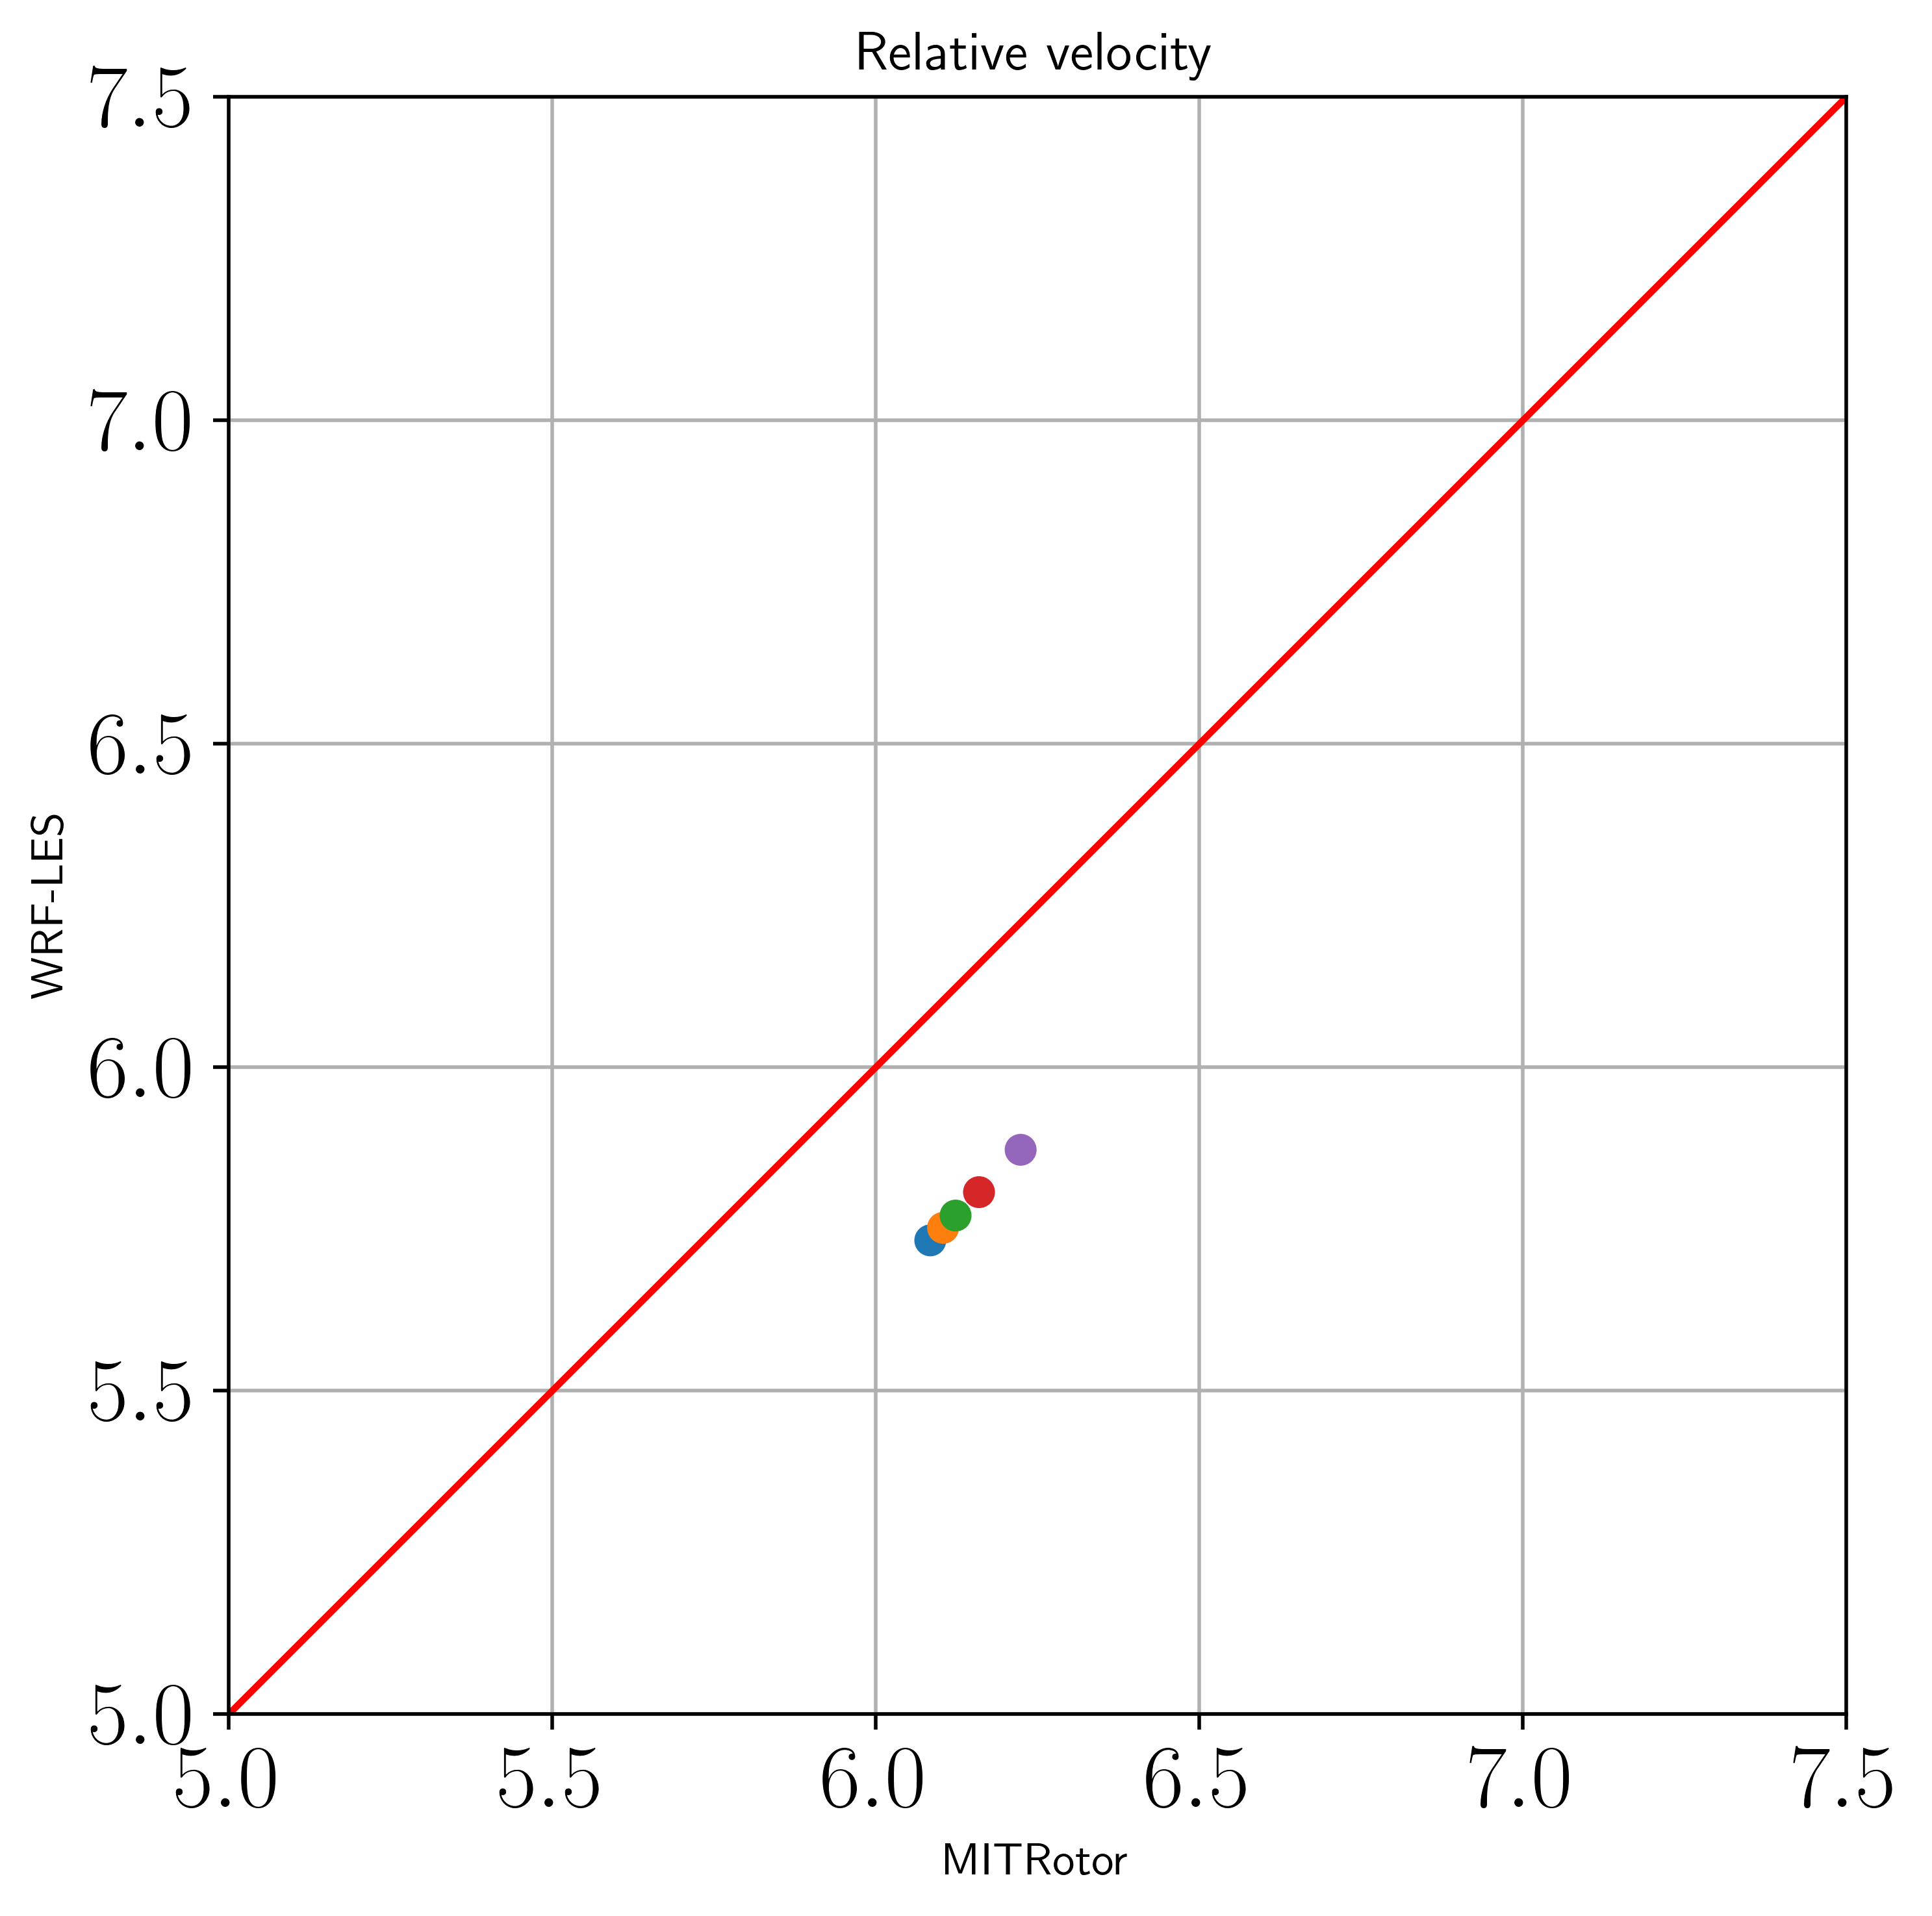

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr


# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(w)):
    ax.scatter(w[i], W_rotor[ind_ubar[i]], s=50, edgecolor='none', color=colors[i])
ax.plot([0,10],[0,10],color='r')

ax.set_xlim([5,7.5])
ax.set_ylim([5,7.5])
ax.set_aspect('equal')

plt.title(f"Relative velocity")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

In [211]:
w

array([6.05763239, 6.07717722, 6.09601497, 6.13109098, 6.1914639 ])

In [212]:
W_rotor

array([5.73320781, 5.73478274, 5.73573514, 5.73575803, 5.73550406,
       5.73502559, 5.73423099, 5.73160905, 5.72770232, 5.73269195,
       5.73382664, 5.73430229, 5.73427794, 5.7340592 , 5.73362548,
       5.73297966, 5.73111915, 5.72755425, 5.73232299, 5.73314198,
       5.73343412, 5.73338852, 5.73317598, 5.73276927, 5.73218426,
       5.73060318, 5.72743702, 5.73213895, 5.7328608 , 5.73309949,
       5.73304652, 5.73283562, 5.73243738, 5.73187156, 5.7303731 ,
       5.72733811, 5.73218749, 5.73298962, 5.73326939, 5.73322887,
       5.73301959, 5.73261185, 5.73202297, 5.73045973, 5.72732468,
       5.73243508, 5.73353926, 5.73397193, 5.73394952, 5.73373503,
       5.73330054, 5.73265785, 5.73085811, 5.72735118, 5.73283065,
       5.73438563, 5.73524502, 5.73527299, 5.73503374, 5.73455127,
       5.73376773, 5.73128623, 5.7274281 ])

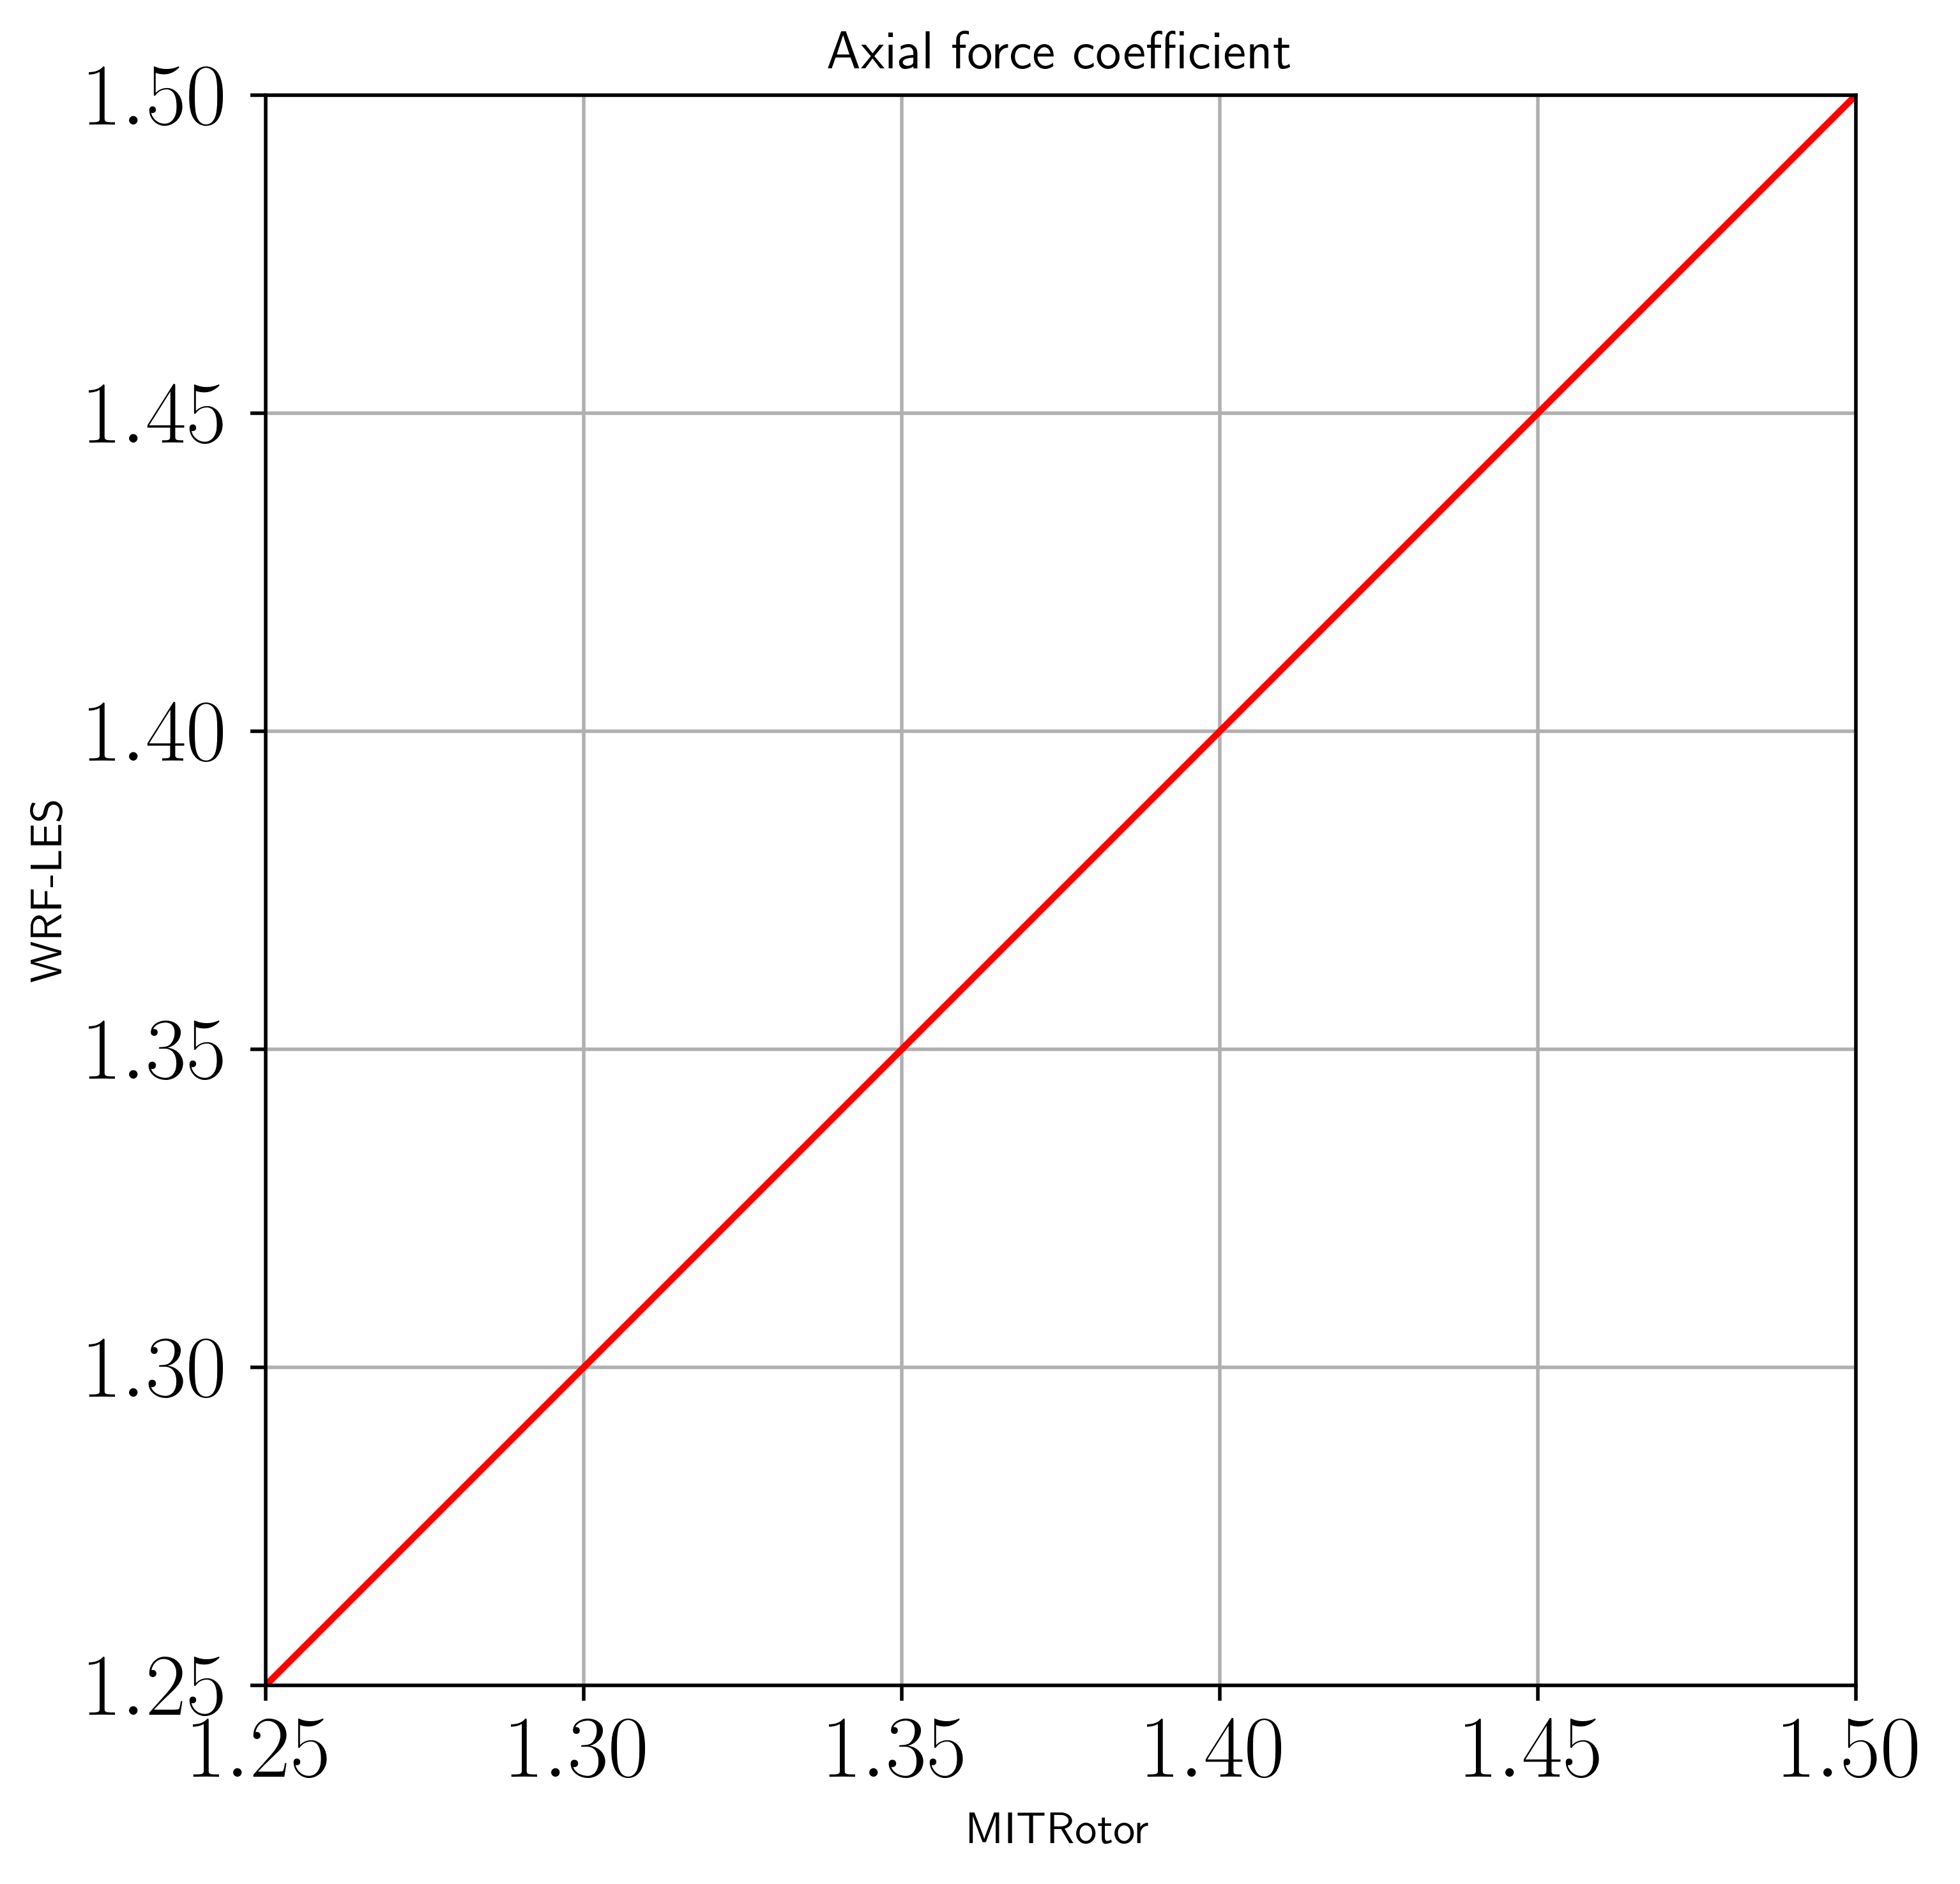

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

# Example data
np.random.seed(42)
x = ct
y = CT

# Compute Pearson correlation
corr_coef, p_value = pearsonr(x, y)

# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(ct)):
    ax.scatter(cx_rotor[i], cx[i], s=50, edgecolor='none', color=colors[i])
ax.plot([1.25,1.5],[1.25,1.5],color='r')

ax.set_xlim([1.25,1.5])
ax.set_ylim([1.25,1.5])
ax.set_aspect('equal')

plt.title(f"Axial force coefficient")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()